# Individual Project - Predicting Depression from Worry-Stress Profiles

Project Introduction: 

This project examines if worry-stress profiles can predict depression severity in university students and if distinct phenotypes related to rumination emerge. This work falls in the domain of psychology, specifically affective science and clinical psychology, and conceptually treats generalized worry and perceived stress as repetitive negative thinking processes closely related to rumination.

This project stems from my theoretical interest in rumination - which is a sustained, self-focused negative thought pattern - I selected a substantial worry-stress dataset. In this context, the Generalized Anxiety Disorder 7-item scale (GAD-7), Perceived Stress Scale (PSS), and Insomnia Severity Index (ISI) serve as practical, rumination-adjacent proxies that effectively capture similar dynamics of repetitive negative thinking at a behavioral level.

Author: Judy Chen

## This notebook does the following things:
1. Exploratory Data Analysis (EDA)
2. Model Exploration - Supervised Learning
3. Model Exploration - Unsupervised Learning
4. Result Analysis
5. Summary & Conclusion


In [189]:
!pip install statsmodels

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')

## Exploratory Analysis

In [191]:
print("="*80)
print("STEP 1: LOAD AND MERGE DATA")
print("="*80)

# Load all CSV files
demographic = pd.read_csv('Xinxiang_dataset/demographic.csv')
phq9 = pd.read_csv('Xinxiang_dataset/phq9.csv')
gad7 = pd.read_csv('Xinxiang_dataset/gad7.csv')
pss = pd.read_csv('Xinxiang_dataset/pss.csv')
isi = pd.read_csv('Xinxiang_dataset/isi.csv')

print(f"\nDemographic shape: {demographic.shape}")
print(f"PHQ-9 shape: {phq9.shape}")
print(f"GAD-7 shape: {gad7.shape}")
print(f"PSS shape: {pss.shape}")
print(f"ISI shape: {isi.shape}")

# p.s. There are more columns than the number of questions because the csv include time columns

STEP 1: LOAD AND MERGE DATA

Demographic shape: (24292, 6)
PHQ-9 shape: (24292, 20)
GAD-7 shape: (24292, 16)
PSS shape: (24292, 30)
ISI shape: (24292, 16)


In [192]:
# Rename score columns before merging to avoid conflicts
phq9 = phq9.rename(columns={'score': 'phq9_total'})
gad7 = gad7.rename(columns={'score': 'gad7_total'})
pss  = pss.rename(columns={'score': 'pss_total'})
isi  = isi.rename(columns={'score': 'isi_total'})

# Rename item columns with scale prefixes BEFORE merging so all items get
# a consistent gad7_qN / pss_qN / isi_qN name regardless of merge order.
# (Without this, PSS items 10-14 would get no suffix because PHQ-9 only
# has 9 items, so question10-14 from PSS would never conflict.)
gad7 = gad7.rename(columns={f'question{i}': f'gad7_q{i}' for i in range(1, 8)})
pss  = pss.rename(columns={f'question{i}': f'pss_q{i}'  for i in range(1, 15)})
isi  = isi.rename(columns={f'question{i}': f'isi_q{i}'  for i in range(1, 8)})

# Keep only the columns we need before merging.
# The raw CSVs also contain time1-time7 (and other) columns that appear in
# multiple DataFrames and would cause MergeError even with suffixes.
# Selecting up front is cleaner than trying to disambiguate them.
phq9 = phq9[['export_id', 'phq9_total']]   # PHQ-9 items not used as predictors
gad7 = gad7[['export_id', 'gad7_total'] + [f'gad7_q{i}' for i in range(1, 8)]]
pss  = pss[['export_id', 'pss_total']   + [f'pss_q{i}'  for i in range(1, 15)]]
isi  = isi[['export_id', 'isi_total']   + [f'isi_q{i}'  for i in range(1, 8)]]

# Merge — no conflicts remain
df = demographic.merge(phq9, on='export_id', how='inner') \
                .merge(gad7, on='export_id', how='inner') \
                .merge(pss,  on='export_id', how='inner') \
                .merge(isi,  on='export_id', how='inner')

print(f"\nMerged dataset shape: {df.shape}")
print(f"Number of participants: {df['export_id'].nunique()}")


Merged dataset shape: (24292, 38)
Number of participants: 24292


In [193]:
print("\n" + "="*80)
print("STEP 2: DATA QUALITY CHECKS")
print("="*80)

# Check for missing values in key columns
key_cols = ['export_id', 'gender', 'age', 'edu', 'smoke', 'drink', 
            'phq9_total', 'gad7_total', 'pss_total', 'isi_total']

missing = df[key_cols].isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values in key columns!")

# Check for duplicates
duplicates = df.duplicated(subset='export_id').sum()
print(f"\nDuplicate export_ids: {duplicates}")

# Check value ranges for total scores
print("\nScore Range Validation:")
print(f"PHQ-9 total (expected 0-27): [{df['phq9_total'].min()}, {df['phq9_total'].max()}]")
print(f"GAD-7 total (expected 0-21): [{df['gad7_total'].min()}, {df['gad7_total'].max()}]")
print(f"PSS total (expected 0-56): [{df['pss_total'].min()}, {df['pss_total'].max()}]")
print(f"ISI total (expected 0-28): [{df['isi_total'].min()}, {df['isi_total'].max()}]")

# Check age validity
print(f"\nAge range: [{df['age'].min()}, {df['age'].max()}]")
age_under_17 = df[df['age'] < 17].shape[0]
print(f"Participants younger than 17: {age_under_17}")


STEP 2: DATA QUALITY CHECKS
No missing values in key columns!

Duplicate export_ids: 0

Score Range Validation:
PHQ-9 total (expected 0-27): [0, 27]
GAD-7 total (expected 0-21): [0, 21]
PSS total (expected 0-56): [0, 56]
ISI total (expected 0-28): [0, 28]

Age range: [1.0, 99.0]
Participants younger than 17: 32


In [194]:
print("\n" + "="*80)
print("STEP 3: DESCRIPTIVE STATISTICS")
print("="*80)

# Numerical variables summary
numerical_vars = ['age', 'phq9_total', 'gad7_total', 'pss_total', 'isi_total']
print("\nDescriptive Statistics:")
print(df[numerical_vars].describe().round(2))

# Categorical variables distribution
print("\n" + "-"*80)
print("Gender Distribution:")
print(df['gender'].value_counts())
print(f"\nProportion:")
print(df['gender'].value_counts(normalize=True).round(3))

print("\n" + "-"*80)
print("Education Level Distribution:")
print(df['edu'].value_counts())

print("\n" + "-"*80)
print("Smoking Status Distribution (Top 5):")
print(df['smoke'].value_counts().head())

print("\n" + "-"*80)
print("Drinking Status Distribution (Top 5):")
print(df['drink'].value_counts().head())


STEP 3: DESCRIPTIVE STATISTICS

Descriptive Statistics:
            age  phq9_total  gad7_total  pss_total  isi_total
count  24292.00    24292.00    24292.00   24292.00   24292.00
mean      20.66        3.27        1.91      19.99       2.78
std        2.41        3.71        2.92       8.32       3.44
min        1.00        0.00        0.00       0.00       0.00
25%       19.00        0.00        0.00      14.00       0.00
50%       20.00        2.00        0.00      20.00       2.00
75%       22.00        5.00        3.00      27.00       4.00
max       99.00       27.00       21.00      56.00      28.00

--------------------------------------------------------------------------------
Gender Distribution:
gender
female    15545
male       8747
Name: count, dtype: int64

Proportion:
gender
female    0.64
male      0.36
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Education Level Distribution:
edu
bachelor's degree 

In [195]:
print("\n" + "="*80)
print("STEP 4: CREATE TARGET VARIABLES")
print("="*80)

# Continuous target: PHQ-9 total score
df['depression_continuous'] = df['phq9_total']

# Binary target: PHQ-9 >= 10 (clinically significant depression)
df['depression_binary'] = (df['phq9_total'] >= 10).astype(int)

print(f"\nContinuous target (PHQ-9 total) statistics:")
print(df['depression_continuous'].describe().round(2))

print(f"\nBinary target (PHQ-9 >= 10) distribution:")
print(df['depression_binary'].value_counts())
print(f"Proportion with clinical depression (PHQ-9 >= 10): {df['depression_binary'].mean():.3f}")

# Create severity categories for PHQ-9
df['phq9_severity'] = pd.cut(df['phq9_total'], 
                              bins=[-1, 4, 9, 14, 19, 27],
                              labels=['none-minimal', 'mild', 'moderate', 
                                      'moderately-severe', 'severe'])
print(f"\nPHQ-9 Severity Distribution:")
print(df['phq9_severity'].value_counts().sort_index())

# Create severity categories for other scales
df['gad7_severity'] = pd.cut(df['gad7_total'],
                              bins=[-1, 4, 9, 14, 21],
                              labels=['minimal', 'mild', 'moderate', 'severe'])

# PSS-14 severity cutoffs (0-56 range)
df['pss_severity'] = pd.cut(df['pss_total'],
                             bins=[-1, 18, 36, 56],
                             labels=['low', 'moderate', 'high'])

print(f"\nGAD-7 Severity Distribution:")
print(df['gad7_severity'].value_counts().sort_index())

print(f"\nPSS-14 Severity Distribution:")
print(df['pss_severity'].value_counts().sort_index())


STEP 4: CREATE TARGET VARIABLES

Continuous target (PHQ-9 total) statistics:
count    24292.00
mean         3.27
std          3.71
min          0.00
25%          0.00
50%          2.00
75%          5.00
max         27.00
Name: depression_continuous, dtype: float64

Binary target (PHQ-9 >= 10) distribution:
depression_binary
0    22976
1     1316
Name: count, dtype: int64
Proportion with clinical depression (PHQ-9 >= 10): 0.054

PHQ-9 Severity Distribution:
phq9_severity
none-minimal         16886
mild                  6090
moderate               957
moderately-severe      262
severe                  97
Name: count, dtype: int64

GAD-7 Severity Distribution:
gad7_severity
minimal     20170
mild         3576
moderate      386
severe        160
Name: count, dtype: int64

PSS-14 Severity Distribution:
pss_severity
low         10449
moderate    13411
high          432
Name: count, dtype: int64



STEP 5: EXPLORATORY VISUALIZATIONS

Saved figure: scale_distributions.png


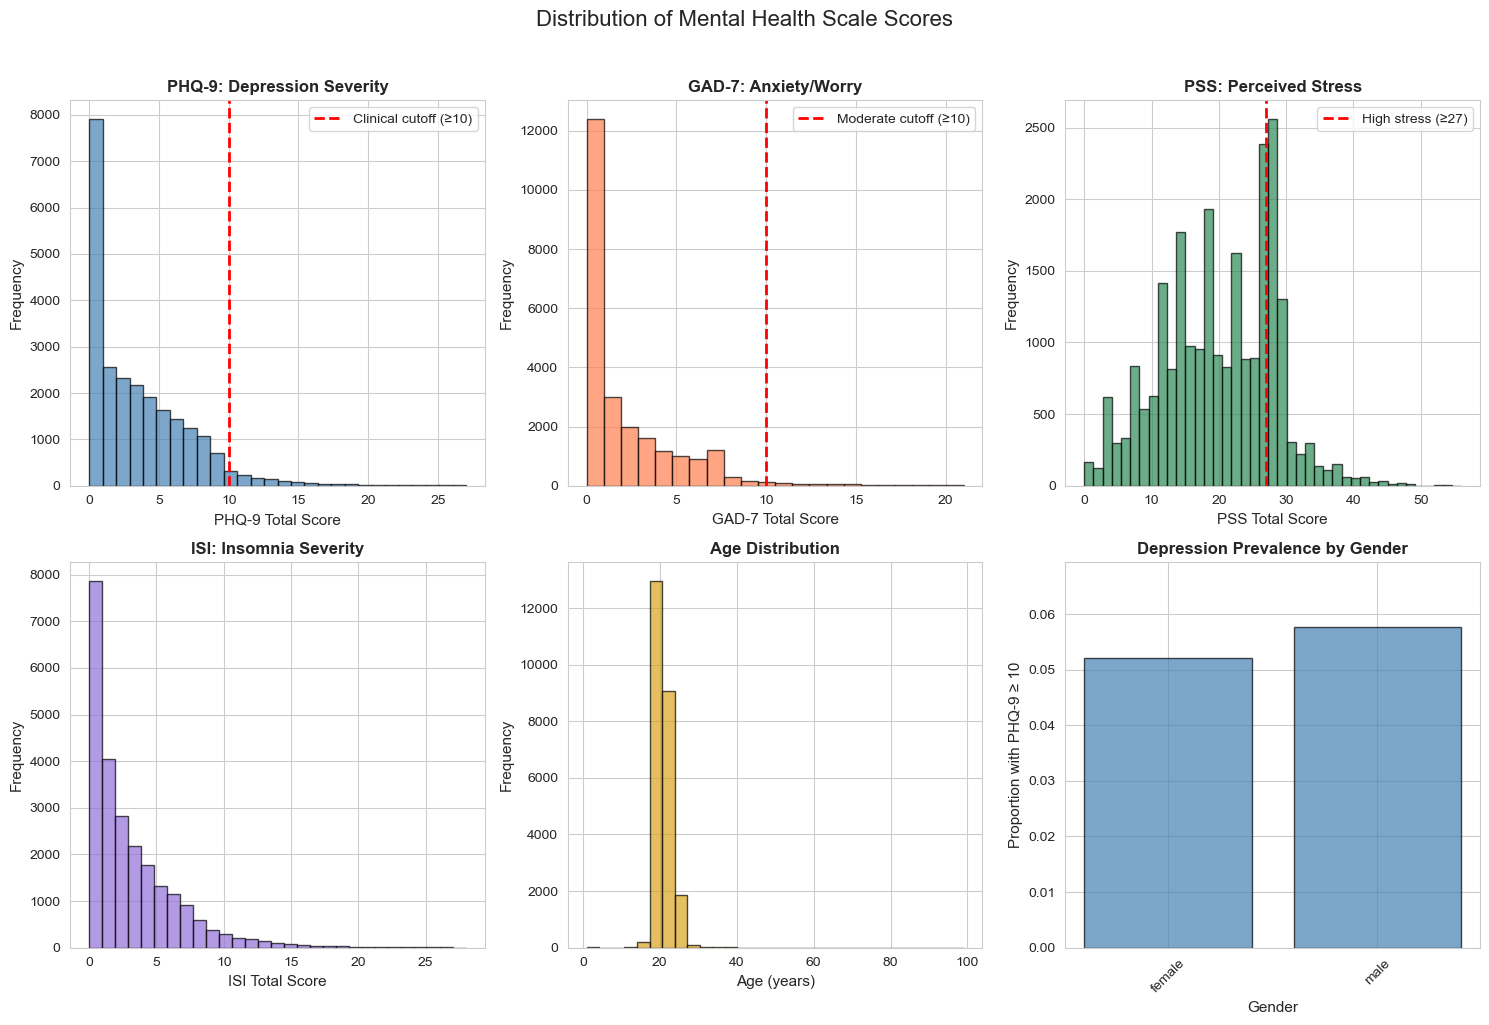

In [196]:
print("\n" + "="*80)
print("STEP 5: EXPLORATORY VISUALIZATIONS")
print("="*80)

# Set up figure for multiple plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Mental Health Scale Scores', fontsize=16, y=1.02)

# PHQ-9 distribution
axes[0, 0].hist(df['phq9_total'], bins=28, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].axvline(10, color='red', linestyle='--', linewidth=2, label='Clinical cutoff (≥10)')
axes[0, 0].set_xlabel('PHQ-9 Total Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('PHQ-9: Depression Severity', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# GAD-7 distribution
axes[0, 1].hist(df['gad7_total'], bins=22, edgecolor='black', color='coral', alpha=0.7)
axes[0, 1].axvline(10, color='red', linestyle='--', linewidth=2, label='Moderate cutoff (≥10)')
axes[0, 1].set_xlabel('GAD-7 Total Score', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('GAD-7: Anxiety/Worry', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# PSS distribution
axes[0, 2].hist(df['pss_total'], bins=41, edgecolor='black', color='seagreen', alpha=0.7)
axes[0, 2].axvline(27, color='red', linestyle='--', linewidth=2, label='High stress (≥27)')
axes[0, 2].set_xlabel('PSS Total Score', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title('PSS: Perceived Stress', fontsize=12, fontweight='bold')
axes[0, 2].legend()

# ISI distribution
axes[1, 0].hist(df['isi_total'], bins=29, edgecolor='black', color='mediumpurple', alpha=0.7)
axes[1, 0].set_xlabel('ISI Total Score', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('ISI: Insomnia Severity', fontsize=12, fontweight='bold')

# Age distribution
axes[1, 1].hist(df['age'], bins=30, edgecolor='black', color='goldenrod', alpha=0.7)
axes[1, 1].set_xlabel('Age (years)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Age Distribution', fontsize=12, fontweight='bold')

# Depression by Gender
depression_by_gender = df.groupby('gender')['depression_binary'].mean()
axes[1, 2].bar(depression_by_gender.index, depression_by_gender.values, 
               color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Gender', fontsize=11)
axes[1, 2].set_ylabel('Proportion with PHQ-9 ≥ 10', fontsize=11)
axes[1, 2].set_title('Depression Prevalence by Gender', fontsize=12, fontweight='bold')
axes[1, 2].set_ylim([0, max(depression_by_gender.values) * 1.2])
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/scale_distributions.png', dpi=300, bbox_inches='tight')
print("\nSaved figure: scale_distributions.png")
plt.show()


STEP 6: COLLINEARITY ANALYSIS

Pairwise Correlation Matrix
            gad7_total  pss_total  isi_total    age
gad7_total       1.000      0.494      0.602  0.016
pss_total        0.494      1.000      0.397  0.022
isi_total        0.602      0.397      1.000 -0.006
age              0.016      0.022     -0.006  1.000

Highly correlated pairs (|r| > 0.7):
None found

Variance Inflation Factors (VIF):
 Predictor      VIF
gad7_total 1.784003
 isi_total 1.601908
 pss_total 1.350375
       age 1.000990

Interpretation: VIF > 5 suggests moderate collinearity; VIF > 10 suggests severe collinearity.

 No predictor has VIF > 5. Collinearity is not a concern.

 Saved figure: collinearity_analysis.png


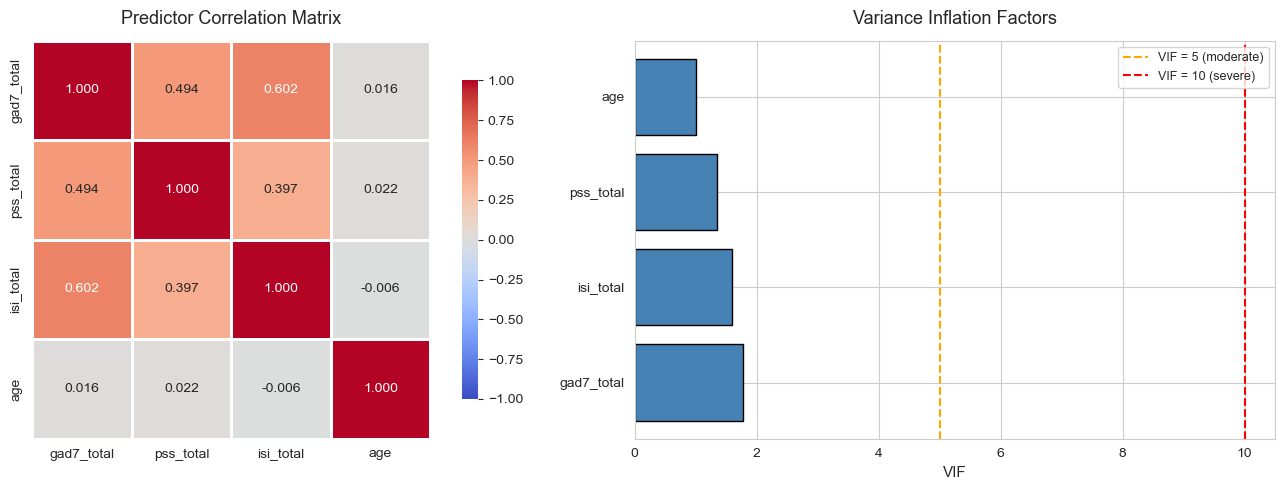

In [197]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n" + "="*80)
print("STEP 6: COLLINEARITY ANALYSIS")
print("="*80)

# Define candidate predictors (excluding PHQ-9 since it's the target)
predictor_vars = ['gad7_total', 'pss_total', 'isi_total', 'age']

# Pairwise correlation matrix ---
corr_matrix = df[predictor_vars].corr()
print("\nPairwise Correlation Matrix")
print(corr_matrix.round(3))

# Flag highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.7):")
high_corr_found = False
for i in range(len(predictor_vars)):
    for j in range(i+1, len(predictor_vars)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {predictor_vars[i]} <-> {predictor_vars[j]}: r = {r:.3f}")
            high_corr_found = True
if not high_corr_found:
    print("None found")

# Variance Inflation Factor (VIF) 
X_vif = df[predictor_vars].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

vif_data = pd.DataFrame({
    'Predictor': predictor_vars,
    'VIF': [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
})
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVariance Inflation Factors (VIF):")
print(vif_data.to_string(index=False))
print("\nInterpretation: VIF > 5 suggests moderate collinearity; VIF > 10 suggests severe collinearity.")

# Flag problematic predictors
high_vif = vif_data[vif_data['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n Predictors with VIF > 5:")
    for _, row in high_vif.iterrows():
        print(f"  {row['Predictor']}: VIF = {row['VIF']:.2f}")
else:
    print("\n No predictor has VIF > 5. Collinearity is not a concern.")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Predictor Correlation Matrix', fontsize=13, pad=12)

# VIF bar chart
bars = axes[1].barh(vif_data['Predictor'], vif_data['VIF'], color='steelblue', edgecolor='black')
axes[1].axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='VIF = 5 (moderate)')
axes[1].axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='VIF = 10 (severe)')
axes[1].set_xlabel('VIF', fontsize=11)
axes[1].set_title('Variance Inflation Factors', fontsize=13, pad=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/collinearity_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved figure: collinearity_analysis.png")
plt.show()


STEP 7: BIVARIATE RELATIONSHIPS WITH DEPRESSION
Saved figure: bivariate_relationships.png


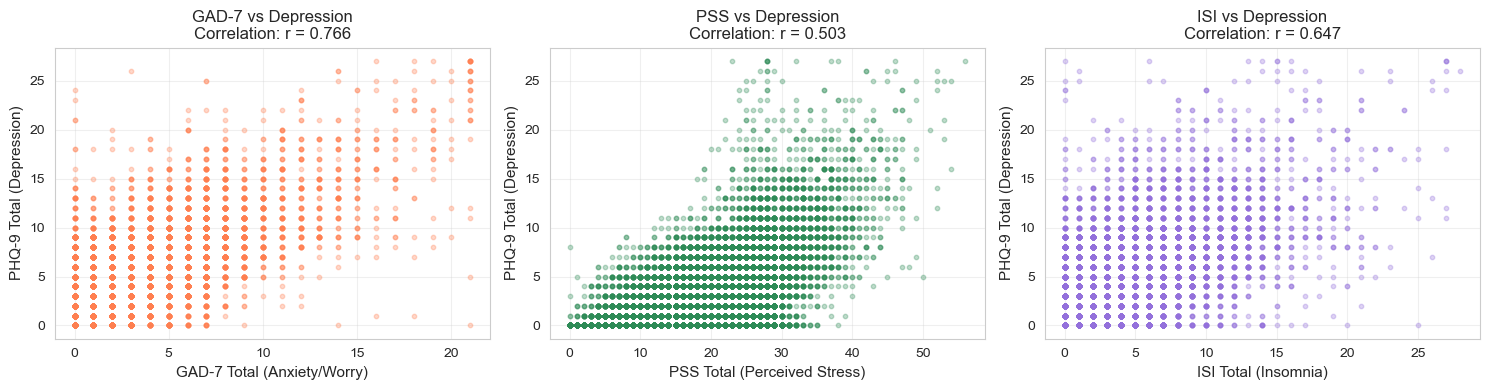

In [198]:
print("\n" + "="*80)
print("STEP 7: BIVARIATE RELATIONSHIPS WITH DEPRESSION")
print("="*80)

# Scatter plot matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# GAD-7 vs PHQ-9
axes[0].scatter(df['gad7_total'], df['phq9_total'], alpha=0.3, s=10, color='coral')
axes[0].set_xlabel('GAD-7 Total (Anxiety/Worry)', fontsize=11)
axes[0].set_ylabel('PHQ-9 Total (Depression)', fontsize=11)
r_gad = df['gad7_total'].corr(df['phq9_total'])
axes[0].set_title(f"GAD-7 vs Depression\nCorrelation: r = {r_gad:.3f}", fontsize=12)
axes[0].grid(alpha=0.3)

# PSS vs PHQ-9
axes[1].scatter(df['pss_total'], df['phq9_total'], alpha=0.3, s=10, color='seagreen')
axes[1].set_xlabel('PSS Total (Perceived Stress)', fontsize=11)
axes[1].set_ylabel('PHQ-9 Total (Depression)', fontsize=11)
r_pss = df['pss_total'].corr(df['phq9_total'])
axes[1].set_title(f"PSS vs Depression\nCorrelation: r = {r_pss:.3f}", fontsize=12)
axes[1].grid(alpha=0.3)

# ISI vs PHQ-9
axes[2].scatter(df['isi_total'], df['phq9_total'], alpha=0.3, s=10, color='mediumpurple')
axes[2].set_xlabel('ISI Total (Insomnia)', fontsize=11)
axes[2].set_ylabel('PHQ-9 Total (Depression)', fontsize=11)
r_isi = df['isi_total'].corr(df['phq9_total'])
axes[2].set_title(f"ISI vs Depression\nCorrelation: r = {r_isi:.3f}", fontsize=12)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/bivariate_relationships.png', dpi=300, bbox_inches='tight')
print("Saved figure: bivariate_relationships.png")
plt.show()

In [199]:
print("\n" + "="*80)
print("STEP 8a: ENCODE DEMOGRAPHIC VARIABLES")
print("="*80)

# Create a clean dataframe for modeling
df_model = df.copy()

# --- BINARY ENCODING: Gender ---
df_model['gender_encoded'] = (df_model['gender'] == 'male').astype(int)
print("\n Gender encoded (binary): female=0, male=1")
print(df_model[['gender', 'gender_encoded']].drop_duplicates())

# --- ORDINAL ENCODING: Education ---
edu_order = {
    'associate degree': 0,
    "bachelor's degree": 1, 
    "master's degree": 2,
    'doctorate degree': 3
}
df_model['edu_encoded'] = df_model['edu'].map(edu_order)

if df_model['edu_encoded'].isnull().any():
    print("\nWarning: Some education values not mapped:")
    print(df_model[df_model['edu_encoded'].isnull()]['edu'].value_counts())
    df_model['edu_encoded'] = df_model['edu_encoded'].fillna(1)

print("\n Education encoded (ordinal):")
print(df_model[['edu', 'edu_encoded']].drop_duplicates().sort_values('edu_encoded'))

# --- ORDINAL ENCODING: Smoking ---
def simplify_smoke(smoke):
    if 'never' in str(smoke).lower():
        return 'never'
    elif 'occasional' in str(smoke).lower():
        return 'occasional'
    elif 'former' in str(smoke).lower():
        return 'former'
    elif 'current' in str(smoke).lower():
        return 'current'
    else:
        return 'never'

df_model['smoke_simple'] = df_model['smoke'].apply(simplify_smoke)

smoke_order = {'never': 0, 'occasional': 1, 'former': 2, 'current': 3}
df_model['smoke_encoded'] = df_model['smoke_simple'].map(smoke_order)

print("\n Smoking encoded (ordinal): never=0, occasional=1, former=2, current=3")
print(df_model[['smoke_simple', 'smoke_encoded']].drop_duplicates().sort_values('smoke_encoded'))

# --- ORDINAL ENCODING: Drinking ---
def simplify_drink(drink):
    if 'never' in str(drink).lower():
        return 'never'
    elif 'occasionally' in str(drink).lower() or 'less than once a week' in str(drink).lower():
        return 'occasional'
    elif 'past' in str(drink).lower():
        return 'former'
    elif 'regular' in str(drink).lower() or 'more than once a week' in str(drink).lower():
        return 'regular'
    else:
        return 'never'

df_model['drink_simple'] = df_model['drink'].apply(simplify_drink)

drink_order = {'never': 0, 'occasional': 1, 'former': 2, 'regular': 3}
df_model['drink_encoded'] = df_model['drink_simple'].map(drink_order)

print("\n Drinking encoded (ordinal): never=0, occasional=1, former=2, regular=3")
print(df_model[['drink_simple', 'drink_encoded']].drop_duplicates().sort_values('drink_encoded'))


STEP 8a: ENCODE DEMOGRAPHIC VARIABLES

 Gender encoded (binary): female=0, male=1
   gender  gender_encoded
0  female               0
2    male               1

 Education encoded (ordinal):
                   edu  edu_encoded
719   associate degree            0
0    bachelor's degree            1
2      master's degree            2
540   doctorate degree            3

 Smoking encoded (ordinal): never=0, occasional=1, former=2, current=3
    smoke_simple  smoke_encoded
0          never              0
171   occasional              1
126       former              2
7        current              3

 Drinking encoded (ordinal): never=0, occasional=1, former=2, regular=3
    drink_simple  drink_encoded
0          never              0
2     occasional              1
37        former              2
155      regular              3


In [200]:
print("\n" + "="*80)
print("STEP 8b: EXTRACT ITEM-LEVEL SCALE QUESTIONS AS ORDINAL PREDICTORS")
print("="*80)

# Based on TA feedback, don't combine all the individual scale questions into one total score. 
# Instead, treat each one as its own ordinal predictor.
# This keeps small differences in worry and stress profiles and lets the model figure out which specific items are most important for depression.

# Before the merge, items were given scale prefixes (see cell above), so all columns are already named gad7_q1 ... pss_q14 ... isi_q7. 
# There is no need to rename anything else here because everything is treated the same.

# --- GAD-7 Items: 7 items ---
# 0=Not at all, 1=Several days, 2=More than half the days, 3=Nearly every day
gad7_item_cols = [f'gad7_q{i}' for i in range(1, 8)]
print(f"\n✓ GAD-7 items: {gad7_item_cols}")
print(f"  Ordinal scale: 0 (not at all) → 3 (nearly every day)")
print(f"  Value range: {df_model[gad7_item_cols].min().min()} – {df_model[gad7_item_cols].max().max()}")

# --- PSS-14 Items: 14 items ---
# 1=Never, 2=Almost never, 3=Sometimes, 4=Fairly often, 5=Very often
# All 14 items (q1-q14) share the same pss_ prefix — no special-casing needed.
pss_item_cols = [f'pss_q{i}' for i in range(1, 15)]
print(f"\n✓ PSS-14 items: {pss_item_cols}")
print(f"  Ordinal scale: 1 (never) → 5 (very often)")
print(f"  Note: PSS items 4,5,7,8 are positively framed (lower score = lower stress).")
print(f"        Models learn directionality automatically; no reverse-coding needed.")
print(f"  Value range: {df_model[pss_item_cols].min().min()} – {df_model[pss_item_cols].max().max()}")

# --- ISI Items: 7 items ---
# 0=No problem, 1=Mild, 2=Moderate, 3=Severe, 4=Very severe
isi_item_cols = [f'isi_q{i}' for i in range(1, 8)]
print(f"\n✓ ISI items: {isi_item_cols}")
print(f"  Ordinal scale: 0 (no problem) → 4 (very severe)")
print(f"  Value range: {df_model[isi_item_cols].min().min()} – {df_model[isi_item_cols].max().max()}")

# --- Summary ---
all_item_cols = gad7_item_cols + pss_item_cols + isi_item_cols
print(f"\n{'='*60}")
print(f"Total item-level predictor columns: {len(all_item_cols)}")
print(f"  7 GAD-7 + 14 PSS + 7 ISI = {len(all_item_cols)} items")
print(f"  + 4 demographic features = {len(all_item_cols)+4} total predictors")
print(f"\nNote: Age is dropped (no meaningful relationship with depression, r ≈ 0).")
print(f"  Demographic predictors: gender, education, smoking, drinking.")


STEP 8b: EXTRACT ITEM-LEVEL SCALE QUESTIONS AS ORDINAL PREDICTORS

✓ GAD-7 items: ['gad7_q1', 'gad7_q2', 'gad7_q3', 'gad7_q4', 'gad7_q5', 'gad7_q6', 'gad7_q7']
  Ordinal scale: 0 (not at all) → 3 (nearly every day)
  Value range: 0 – 3

✓ PSS-14 items: ['pss_q1', 'pss_q2', 'pss_q3', 'pss_q4', 'pss_q5', 'pss_q6', 'pss_q7', 'pss_q8', 'pss_q9', 'pss_q10', 'pss_q11', 'pss_q12', 'pss_q13', 'pss_q14']
  Ordinal scale: 1 (never) → 5 (very often)
  Note: PSS items 4,5,7,8 are positively framed (lower score = lower stress).
        Models learn directionality automatically; no reverse-coding needed.
  Value range: 1 – 5

✓ ISI items: ['isi_q1', 'isi_q2', 'isi_q3', 'isi_q4', 'isi_q5', 'isi_q6', 'isi_q7']
  Ordinal scale: 0 (no problem) → 4 (very severe)
  Value range: 0 – 4

Total item-level predictor columns: 28
  7 GAD-7 + 14 PSS + 7 ISI = 28 items
  + 4 demographic features = 32 total predictors

Note: Age is dropped (no meaningful relationship with depression, r ≈ 0).
  Demographic predicto

In [226]:
print("\n" + "="*80)
print("STEP 9: PREPARE MODELING DATASET (ITEM-LEVEL PREDICTORS)")
print("="*80)

# Item-level ordinal predictors (per TA feedback)
gad7_item_cols = [f'gad7_q{i}' for i in range(1, 8)]   # 7 items, ordinal 0-3
pss_item_cols  = [f'pss_q{i}'  for i in range(1, 15)]  # 14 items, ordinal 1-5
isi_item_cols  = [f'isi_q{i}'  for i in range(1, 8)]   # 7 items, ordinal 0-4
demographic_cols = ['gender_encoded', 'edu_encoded', 'smoke_encoded', 'drink_encoded']

predictor_cols = gad7_item_cols + pss_item_cols + isi_item_cols + demographic_cols

# Target variables
target_continuous = 'phq9_total'
target_binary = 'depression_binary'

# Create feature matrix and targets
X = df_model[predictor_cols].copy()
y_continuous = df_model[target_continuous].copy()
y_binary = df_model[target_binary].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"  {len(gad7_item_cols)} GAD-7 items (ordinal 0-3): {gad7_item_cols}")
print(f"  {len(pss_item_cols)} PSS-14 items (ordinal 1-5): {pss_item_cols}")
print(f"  {len(isi_item_cols)} ISI items (ordinal 0-4): {isi_item_cols}")
print(f"  {len(demographic_cols)} demographic features: {demographic_cols}")

print(f"\nTarget (continuous) — PHQ-9 total:")
print(y_continuous.describe().round(2))

print(f"\nTarget (binary) — PHQ-9 ≥ 10 (clinical depression):")
print(y_binary.value_counts())
imbalance_ratio = y_binary.value_counts()[0] / y_binary.value_counts()[1]
print(f"  Class imbalance ratio (negative:positive) = {imbalance_ratio:.1f}:1")
print(f"  Only {y_binary.mean()*100:.1f}% of samples are positive (depressed).")
print(f"  Strategies: class_weight='balanced', SMOTE, and threshold tuning.")

# Check for missing values
print(f"\nMissing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y_binary: {y_binary.isnull().sum()}")

# Collinearity note
print(f"\n--- Collinearity Note ---")
print(f"Items on each scale should be moderately to highly correlated")
print(f"which means they measure the same underlying construct")
print(f"L1/L2 regularization in linear models will fix this within-scale collinearity,")
print(f"and tree-based models naturally handle it by splitting one feature at a time.")


STEP 9: PREPARE MODELING DATASET (ITEM-LEVEL PREDICTORS)

Feature matrix shape: (24292, 32)
  7 GAD-7 items (ordinal 0-3): ['gad7_q1', 'gad7_q2', 'gad7_q3', 'gad7_q4', 'gad7_q5', 'gad7_q6', 'gad7_q7']
  14 PSS-14 items (ordinal 1-5): ['pss_q1', 'pss_q2', 'pss_q3', 'pss_q4', 'pss_q5', 'pss_q6', 'pss_q7', 'pss_q8', 'pss_q9', 'pss_q10', 'pss_q11', 'pss_q12', 'pss_q13', 'pss_q14']
  7 ISI items (ordinal 0-4): ['isi_q1', 'isi_q2', 'isi_q3', 'isi_q4', 'isi_q5', 'isi_q6', 'isi_q7']
  4 demographic features: ['gender_encoded', 'edu_encoded', 'smoke_encoded', 'drink_encoded']

Target (continuous) — PHQ-9 total:
count    24292.00
mean         3.27
std          3.71
min          0.00
25%          0.00
50%          2.00
75%          5.00
max         27.00
Name: phq9_total, dtype: float64

Target (binary) — PHQ-9 ≥ 10 (clinical depression):
depression_binary
0    22976
1     1316
Name: count, dtype: int64
  Class imbalance ratio (negative:positive) = 17.5:1
  Only 5.4% of samples are positive (dep


STEP 9b: WITHIN-SCALE ITEM COLLINEARITY
Saved figure: item_collinearity.png


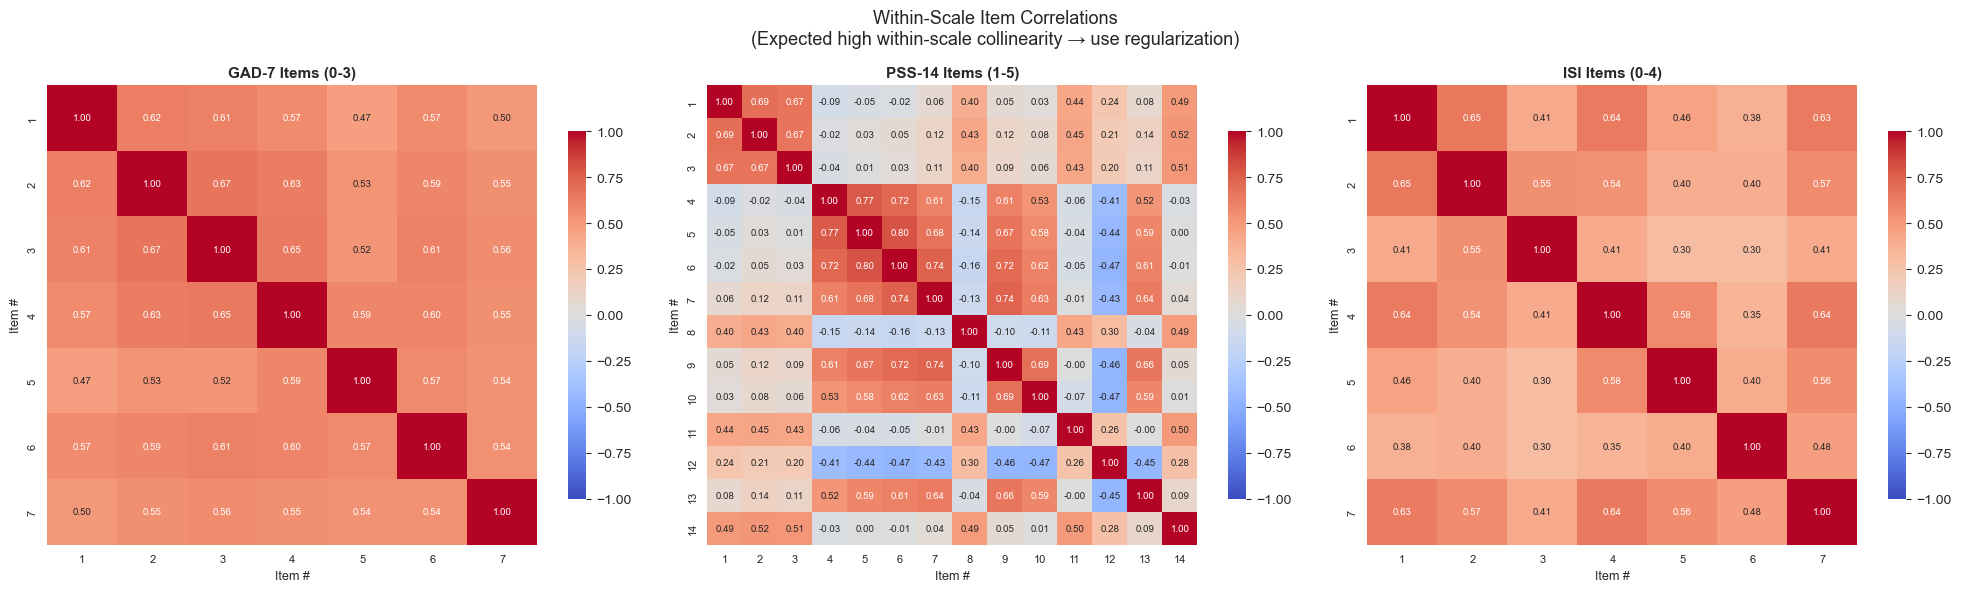

  GAD-7 Items (0-3): mean inter-item r = 0.574
  PSS-14 Items (1-5): mean inter-item r = 0.216
  ISI Items (0-4): mean inter-item r = 0.479


In [ ]:
print("\n" + "="*80)
print("STEP 9b: WITHIN-SCALE ITEM COLLINEARITY")
print("="*80)

# Show correlation heatmaps for all the items on each scale
# This shows that there is collinearity within the scale and that regularization is needed in modeling.

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Within-Scale Item Correlations\n(Expected high within-scale collinearity → use regularization)', 
             fontsize=13)

scales = [
    (gad7_item_cols, 'GAD-7 Items (0-3)'),
    (pss_item_cols,  'PSS-14 Items (1-5)'),
    (isi_item_cols,  'ISI Items (0-4)')
]

for ax, (cols, title) in zip(axes, scales):
    corr = df_model[cols].corr()
    # Rename for readability
    short_labels = [c.split('_q')[1] for c in cols]  # just the number
    corr.columns = short_labels
    corr.index = short_labels
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, ax=ax, cbar_kws={"shrink": 0.8},
                annot_kws={"size": 7})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Item #', fontsize=9)
    ax.set_ylabel('Item #', fontsize=9)
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.savefig('figures/item_collinearity.png', dpi=300, bbox_inches='tight')
print("Saved figure: item_collinearity.png")
plt.show()

# Flag which scale has the highest mean inter-item correlation
for cols, name in scales:
    corr_m = df_model[cols].corr()
    # Mask diagonal
    mask = ~np.eye(len(cols), dtype=bool)
    mean_r = corr_m.values[mask].mean()
    print(f"  {name}: mean inter-item r = {mean_r:.3f}")

In [ ]:
print("\n" + "="*80)
print("STEP 10: TRAIN-TEST SPLIT + STANDARDIZATION FOR LINEAR MODELS")
print("="*80)

# -- Binary classification split (stratified to preserve imbalance ratio) --
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\nClassification splits (stratified):")
print(f"  Training set: {X_train_cls.shape[0]} samples")
print(f"  Test set:     {X_test_cls.shape[0]} samples")
print(f"  Training depression rate: {y_train_cls.mean():.4f}")
print(f"  Test depression rate:     {y_test_cls.mean():.4f}")

# -- Standardize X for logistic regression (tree models use raw ordinal values) --
# Logistic regression is sensitive to feature scale; decision trees are not.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cls)   # fit on TRAIN only
X_test_scaled  = scaler.transform(X_test_cls)         # apply same transform to TEST

X_train_scaled = pd.DataFrame(X_train_scaled, columns=predictor_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=predictor_cols)

print(f"\n Standardized feature matrices ready for logistic regression:")
print(f"  X_train_scaled: {X_train_scaled.shape} | X_test_scaled: {X_test_scaled.shape}")
print(f"\n Raw (ordinal integer) matrices ready for tree-based models:")
print(f"  X_train_cls: {X_train_cls.shape} | X_test_cls: {X_test_cls.shape}")

# Continuous target split (for regression task, if needed)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_continuous, test_size=0.2, random_state=42
)
print(f"\nRegression splits (optional, PHQ-9 continuous):")
print(f"  Training set: {X_train_reg.shape[0]} | Test set: {X_test_reg.shape[0]}")


STEP 10: TRAIN-TEST SPLIT + STANDARDIZATION FOR LINEAR MODELS

Classification splits (stratified):
  Training set: 19433 samples
  Test set:     4859 samples
  Training depression rate: 0.0542
  Test depression rate:     0.0541

 Standardized feature matrices ready for logistic regression:
  X_train_scaled: (19433, 32) | X_test_scaled: (4859, 32)

 Raw (ordinal integer) matrices ready for tree-based models:
  X_train_cls: (19433, 32) | X_test_cls: (4859, 32)

Regression splits (optional, PHQ-9 continuous):
  Training set: 19433 | Test set: 4859


## Section II: Supervised Learning

**Goal:** Predict clinical depression (PHQ-9 >= 10) from 28 item-level worry-stress predictors (GAD-7, PSS-14, ISI) and 4 demographic features.

**Class imbalance:** 94.6% negative vs. 5.4% positive (17:1 ratio). Accuracy is a misleading metric - a trivial "always predict negative" classifier scores 94.6%. We instead optimise for:
- **Macro F1** - balanced performance across both classes
- **Minority Recall** — proportion of depressed cases caught (clinical priority)
- **ROC-AUC** — overall discrimination ability

**Models trained:**

| Family | IDs | Imbalance Strategies |
|--------|-----|---------------------|
| Logistic Regression | LR-1 -> LR-7 | Baseline, class weights, L1/L2 regularization, SMOTE, undersampling, threshold tuning |
| Decision Tree | DT-1 -> DT-5 | Baseline, class weights, SMOTE, undersampling, threshold tuning |

**Feature inputs:**
- LR models use `X_train_scaled` (standardized) - LR is scale-sensitive
- DT models use `X_train_cls` (raw ordinal integers) - trees are scale-invariant


In [228]:
import warnings
warnings.filterwarnings('ignore')

# -- Install imbalanced-learn if not present --
try:
    import imblearn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, recall_score, precision_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# -- Cross-validation scheme (stratified to preserve imbalance) --
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -- Results storage (filled by evaluate_model) --
results = []

print("All supervised modeling imports ready.")
print(f"  Training: {X_train_cls.shape} samples | Test: {X_test_cls.shape} samples")
print(f"  Positive rate — train: {y_train_cls.mean():.4f} | test: {y_test_cls.mean():.4f}")


All supervised modeling imports ready.
  Training: (19433, 32) samples | Test: (4859, 32) samples
  Positive rate — train: 0.0542 | test: 0.0541


In [ ]:

# A helper function to facilitate model evaluation later, so that I don't have to manually tweak this every time
def evaluate_model(name, model, X_test, y_test, threshold=0.5, store=True, verbose=True):
    """
    Evaluate a trained binary classifier and optionally store results.

    Works with plain sklearn estimators and imblearn Pipelines.
    Results are appended to the global `results` list; nothing is returned
    so Jupyter does not auto-display a raw dict in the output cell.
    """
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_prob = None
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    macro_f1      = f1_score(y_test, y_pred, average='macro')
    min_recall    = recall_score(y_test,    y_pred, pos_label=1)
    min_precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    min_f1        = f1_score(y_test,        y_pred, pos_label=1, zero_division=0)
    roc_auc       = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    accuracy      = (tp + tn) / len(y_test)

    if verbose:
        print(f"  {name}")
        print(f"{'─'*62}")
        print(f"  Threshold:           {threshold:.2f}")
        print(f"  Accuracy:            {accuracy:.4f}   <- misleading under imbalance")
        print(f"  Macro F1:            {macro_f1:.4f}")
        print(f"  Minority Recall:     {min_recall:.4f}   <- depressed cases caught")
        print(f"  Minority Precision:  {min_precision:.4f}")
        print(f"  Minority F1:         {min_f1:.4f}")
        if roc_auc is not None:
            print(f"  ROC-AUC:             {roc_auc:.4f}")
        print(f"\n  Confusion Matrix (rows=actual, cols=predicted):")
        print(f"               Pred 0   Pred 1")
        print(f"  Actual 0:  {tn:7d}  {fp:7d}   (true neg / false pos)")
        print(f"  Actual 1:  {fn:7d}  {tp:7d}   (false neg / true pos)")

    row = dict(
        Model=name, Threshold=threshold,
        MacroF1=round(macro_f1, 4),
        MinRecall=round(min_recall, 4),
        MinPrecision=round(min_precision, 4),
        MinF1=round(min_f1, 4),
        ROCAUC=round(roc_auc, 4) if roc_auc is not None else None,
        Accuracy=round(accuracy, 4),
        TP=tp, TN=tn, FP=fp, FN=fn,
    )
    if store:
        results.append(row)
    # No return value — prevents Jupyter from auto-displaying the raw dict


print("evaluate_model() helper defined.")
print("Metrics captured: Macro F1, Minority Recall/Precision/F1, ROC-AUC, Confusion Matrix.")


### 2.1 Logistic Regression

Logistic Regression is the primary linear baseline. I use standardized features (`X_train_scaled`) because LR is sensitive to feature scale. If I used ordinal integers with different ranges (0-3, 1-5, 0-4), the coefficient magnitudes would be wrong.

Seven variants address class imbalance progressively:

| ID | Strategy | Notes |
|----|----------|-------|
| LR-1 | None (baseline) | Shows the imbalance problem directly |
| LR-2 | `class_weight='balanced'` | Algorithm-level; no data change |
| LR-3 | L2 + class weights | Shrinks correlated item coefficients; C tuned by CV |
| LR-4 | L1 + class weights | Sparse solution; automatic feature selection |
| LR-5 | SMOTE oversampling | Synthesises minority examples in feature space |
| LR-6 | Random undersampling (2:1) | Drops majority samples; faster but information loss |
| LR-7 | Threshold tuning on LR-3 | Post-hoc; maximises minority-class F1 |


LR-1: Baseline Logistic Regression  [no imbalance handling]
  Expected: high accuracy but low minority recall — predicts majority class (not-depressed).
  LR-1: Baseline
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.9601   <- misleading under imbalance
  Macro F1:            0.7530
  Minority Recall:     0.4106   <- depressed cases caught
  Minority Precision:  0.7347
  Minority F1:         0.5268
  ROC-AUC:             0.9612

  Confusion Matrix (rows=actual, cols=predicted):
               Pred 0   Pred 1
  Actual 0:     4557       39   (true neg / false pos)
  Actual 1:      155      108   (false neg / true pos)


LR-2: Class-Weighted Logistic Regression  [class_weight='balanced']
  Automatically up-weights the minority class by the inverse class frequency.
  LR-2: Class-Weighted
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.8878   <- misleading

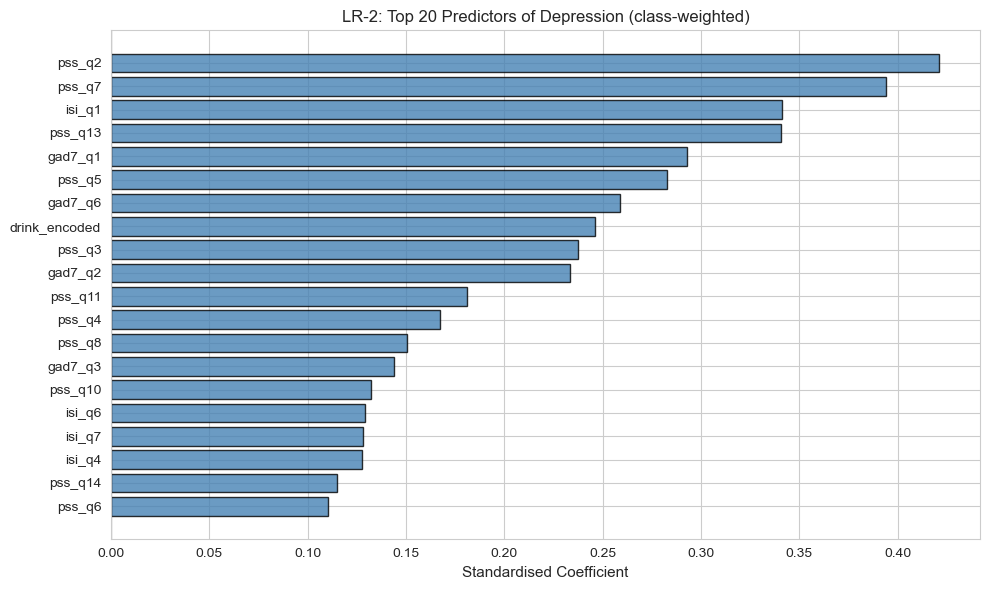

In [236]:

print("=" * 80)
print("LR-1: Baseline Logistic Regression  [no imbalance handling]")
print("  Expected: high accuracy but low minority recall — predicts majority class (not-depressed).")
print("=" * 80)

lr1 = LogisticRegression(max_iter=1000, random_state=42)
lr1.fit(X_train_scaled, y_train_cls)
evaluate_model("LR-1: Baseline", lr1, X_test_scaled, y_test_cls)

print("\n\n" + "=" * 80)
print("LR-2: Class-Weighted Logistic Regression  [class_weight='balanced']")
print("  Automatically up-weights the minority class by the inverse class frequency.")
print("=" * 80)

lr2 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr2.fit(X_train_scaled, y_train_cls)
evaluate_model("LR-2: Class-Weighted", lr2, X_test_scaled, y_test_cls)

# -- Coefficient plot for LR-2 (top predictors) --
coef_df = pd.DataFrame({
    'Feature': predictor_cols,
    'Coefficient': lr2.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised Coefficient', fontsize=11)
ax.set_title('LR-2: Top 20 Predictors of Depression (class-weighted)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/lr2_coefficients.png', dpi=300, bbox_inches='tight')
print("\n Saved: lr2_coefficients.png")
plt.show()


In [ ]:

print("=" * 80)
print("LR-3: L2 Regularization + Class-Weighted  (C tuned via 5-fold CV)")
print("  L2 shrinks all coefficients toward zero — handles within-scale collinearity.")
print("=" * 80)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

gs_l2 = GridSearchCV(
    LogisticRegression(penalty='l2', class_weight='balanced',
                       solver='lbfgs', max_iter=1000, random_state=42),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True
)
gs_l2.fit(X_train_scaled, y_train_cls)
lr3 = gs_l2.best_estimator_
print(f"  Best C (L2): {gs_l2.best_params_['C']}  |  CV Macro F1: {gs_l2.best_score_:.4f}")
evaluate_model("LR-3: L2 + Class-Weighted", lr3, X_test_scaled, y_test_cls)

print("\n\n" + "=" * 80)
print("LR-4: L1 Regularization + Class-Weighted  (C tuned via 5-fold CV)")
print("  L1 pushes some coefficients to exactly zero — built-in feature selection.")
print("=" * 80)

gs_l1 = GridSearchCV(
    LogisticRegression(penalty='l1', class_weight='balanced',
                       solver='liblinear', max_iter=1000, random_state=42),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True
)
gs_l1.fit(X_train_scaled, y_train_cls)
lr4 = gs_l1.best_estimator_
print(f"  Best C (L1): {gs_l1.best_params_['C']}  |  CV Macro F1: {gs_l1.best_score_:.4f}")
evaluate_model("LR-4: L1 + Class-Weighted", lr4, X_test_scaled, y_test_cls)

n_zero = (lr4.coef_[0] == 0).sum()
print(f"\n  L1 zeroed-out {n_zero}/{len(predictor_cols)} features.")
if n_zero > 0:
    zeroed = [c for c, w in zip(predictor_cols, lr4.coef_[0]) if w == 0]
    print(f"  Zeroed predictors: {zeroed}")


LR-3: L2 Regularization + Class-Weighted  (C tuned via 5-fold CV)
  L2 shrinks all coefficients toward zero — handles within-scale collinearity.
  Best C (L2): 0.001  |  CV Macro F1: 0.6936
  LR-3: L2 + Class-Weighted
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.8866   <- misleading under imbalance
  Macro F1:            0.7006
  Minority Recall:     0.9087   <- depressed cases caught
  Minority Precision:  0.3120
  Minority F1:         0.4645
  ROC-AUC:             0.9611

  Confusion Matrix (rows=actual, cols=predicted):
               Pred 0   Pred 1
  Actual 0:     4069      527   (true neg / false pos)
  Actual 1:       24      239   (false neg / true pos)


LR-4: L1 Regularization + Class-Weighted  (C tuned via 5-fold CV)
  L1 pushes some coefficients to exactly zero — built-in feature selection.
  Best C (L1): 10  |  CV Macro F1: 0.6928
  LR-4: L1 + Class-Weighted
─────────────────────────────────────────────

In [208]:

print("=" * 80)
print("LR-5: SMOTE Oversampling + Logistic Regression")
print("  SMOTE synthesises minority examples in feature space.")
print("  Pipeline ensures SMOTE is applied only to training folds — no data leakage.")
print("=" * 80)

pipe_smote_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])
pipe_smote_lr.fit(X_train_scaled, y_train_cls)
evaluate_model("LR-5: SMOTE", pipe_smote_lr, X_test_scaled, y_test_cls)


LR-5: SMOTE Oversampling + Logistic Regression
  SMOTE synthesises minority examples in feature space.
  Pipeline ensures SMOTE is applied only to training folds — no data leakage.

──────────────────────────────────────────────────────────────
  LR-5: SMOTE
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.8885   ← misleading under imbalance
  Macro F1:            0.7026
  Minority Recall:     0.9049   ← depressed cases caught
  Minority Precision:  0.3152
  Minority F1:         0.4676
  ROC-AUC:             0.9603

  Confusion Matrix (rows=actual, cols=predicted):
               Pred 0   Pred 1
  Actual 0:     4079      517   (true neg / false pos)
  Actual 1:       25      238   (false neg / true pos)


({'Model': 'LR-5: SMOTE',
  'Threshold': 0.5,
  'MacroF1': 0.7026,
  'MinRecall': 0.9049,
  'MinPrecision': 0.3152,
  'MinF1': 0.4676,
  'ROCAUC': 0.9603,
  'Accuracy': np.float64(0.8885),
  'TP': np.int64(238),
  'TN': np.int64(4079),
  'FP': np.int64(517),
  'FN': np.int64(25)},
 array([0.72880788, 0.03084983, 0.84251174, ..., 0.56971936, 0.06001565,
        0.0054848 ], shape=(4859,)))

In [209]:

print("=" * 80)
print("LR-6: Random Undersampling + Logistic Regression")
print("  sampling_strategy=0.5  →  majority reduced to 2× minority (softer than 1:1)")
n_min = y_train_cls.value_counts()[1]
n_maj_new = int(n_min / 0.5)
print(f"  Training before: {y_train_cls.value_counts()[0]} neg / {n_min} pos  (17:1)")
print(f"  Training after:  ~{n_maj_new} neg / {n_min} pos  (2:1)")
print("=" * 80)

pipe_under_lr = ImbPipeline([
    ('undersample', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ('clf',         LogisticRegression(max_iter=1000, random_state=42))
])
pipe_under_lr.fit(X_train_scaled, y_train_cls)
evaluate_model("LR-6: Undersampling (2:1)", pipe_under_lr, X_test_scaled, y_test_cls)


LR-6: Random Undersampling + Logistic Regression
  sampling_strategy=0.5  →  majority reduced to 2× minority (softer than 1:1)
  Training before: 18380 neg / 1053 pos  (17:1)
  Training after:  ~2106 neg / 1053 pos  (2:1)

──────────────────────────────────────────────────────────────
  LR-6: Undersampling (2:1)
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.9204   ← misleading under imbalance
  Macro F1:            0.7443
  Minority Recall:     0.8365   ← depressed cases caught
  Minority Precision:  0.3901
  Minority F1:         0.5320
  ROC-AUC:             0.9603

  Confusion Matrix (rows=actual, cols=predicted):
               Pred 0   Pred 1
  Actual 0:     4252      344   (true neg / false pos)
  Actual 1:       43      220   (false neg / true pos)


({'Model': 'LR-6: Undersampling (2:1)',
  'Threshold': 0.5,
  'MacroF1': 0.7443,
  'MinRecall': 0.8365,
  'MinPrecision': 0.3901,
  'MinF1': 0.532,
  'ROCAUC': 0.9603,
  'Accuracy': np.float64(0.9204),
  'TP': np.int64(220),
  'TN': np.int64(4252),
  'FP': np.int64(344),
  'FN': np.int64(43)},
 array([0.41419725, 0.0171848 , 0.75140915, ..., 0.317206  , 0.07416335,
        0.00423596], shape=(4859,)))

LR-7: Threshold Tuning on LR-3 (L2 + Class-Weighted)
  Sweeps classification threshold to maximise minority-class F1.

  Optimal threshold: 0.83
  Minority F1 at optimal threshold: 0.6192


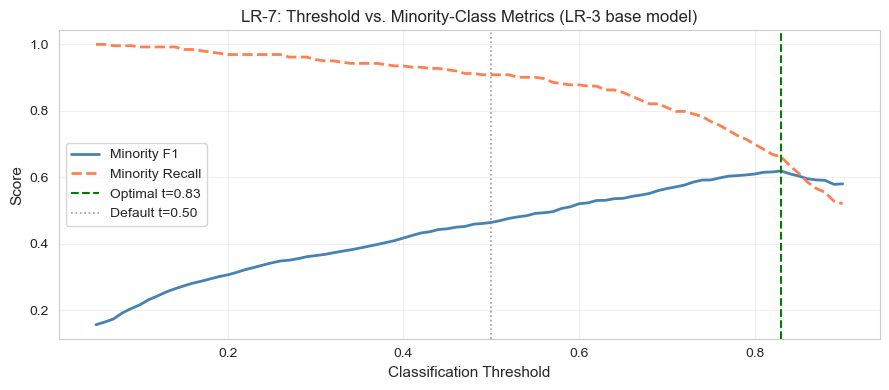


──────────────────────────────────────────────────────────────
  LR-7: Tuned Threshold
──────────────────────────────────────────────────────────────
  Threshold:           0.83
  Accuracy:            0.9560   ← misleading under imbalance
  Macro F1:            0.7979
  Minority Recall:     0.6616   ← depressed cases caught
  Minority Precision:  0.5819
  Minority F1:         0.6192
  ROC-AUC:             0.9611

  Confusion Matrix (rows=actual, cols=predicted):
               Pred 0   Pred 1
  Actual 0:     4471      125   (true neg / false pos)
  Actual 1:       89      174   (false neg / true pos)


({'Model': 'LR-7: Tuned Threshold',
  'Threshold': np.float64(0.8300000000000002),
  'MacroF1': 0.7979,
  'MinRecall': 0.6616,
  'MinPrecision': 0.5819,
  'MinF1': 0.6192,
  'ROCAUC': 0.9611,
  'Accuracy': np.float64(0.956),
  'TP': np.int64(174),
  'TN': np.int64(4471),
  'FP': np.int64(125),
  'FN': np.int64(89)},
 array([0.65866755, 0.05020248, 0.81542706, ..., 0.39891339, 0.12980416,
        0.01581375], shape=(4859,)))

In [210]:

print("=" * 80)
print("LR-7: Threshold Tuning on LR-3 (L2 + Class-Weighted)")
print("  Sweeps classification threshold to maximise minority-class F1.")
print("=" * 80)

y_prob_lr3 = lr3.predict_proba(X_test_scaled)[:, 1]

thresholds   = np.arange(0.05, 0.91, 0.01)
min_f1_vals  = []
min_rec_vals = []

for t in thresholds:
    preds = (y_prob_lr3 >= t).astype(int)
    min_f1_vals.append(f1_score(y_test_cls,     preds, pos_label=1, zero_division=0))
    min_rec_vals.append(recall_score(y_test_cls, preds, pos_label=1, zero_division=0))

best_t_lr   = thresholds[np.argmax(min_f1_vals)]
best_f1_lr  = max(min_f1_vals)
print(f"\n  Optimal threshold: {best_t_lr:.2f}")
print(f"  Minority F1 at optimal threshold: {best_f1_lr:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, min_f1_vals,  color='steelblue', lw=2, label='Minority F1')
ax.plot(thresholds, min_rec_vals, color='coral',     lw=2, linestyle='--', label='Minority Recall')
ax.axvline(best_t_lr, color='green', linestyle='--', lw=1.5, label=f'Optimal t={best_t_lr:.2f}')
ax.axvline(0.5,       color='gray',  linestyle=':',  lw=1.2, alpha=0.8, label='Default t=0.50')
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('LR-7: Threshold vs. Minority-Class Metrics (LR-3 base model)', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/lr_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

evaluate_model("LR-7: Tuned Threshold", lr3, X_test_scaled, y_test_cls, threshold=best_t_lr)


### 2.2 Decision Tree

Decision Trees are non-linear, scale-invariant classifiers. I use raw ordinal features (`X_train_cls`) — no standardization needed. Tree depth is capped at **5** to keep the model interpretable; deeper trees tend to overfit given the 5.4% minority rate.

I apply the same four imbalance strategies as for LR:

| ID | Strategy |
|----|----------|
| DT-1 | Baseline (no adjustment) |
| DT-2 | `class_weight='balanced'` |
| DT-3 | SMOTE oversampling |
| DT-4 | Random undersampling (`sampling_strategy=0.5`) |
| DT-5 | Threshold tuning on best DT model |


DT-1: Baseline Decision Tree  [max_depth=5, no imbalance handling]

──────────────────────────────────────────────────────────────
  DT-1: Baseline
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.9570   ← misleading under imbalance
  Macro F1:            0.7229
  Minority Recall:     0.3498   ← depressed cases caught
  Minority Precision:  0.7077
  Minority F1:         0.4682
  ROC-AUC:             0.9182

  Confusion Matrix (rows=actual, cols=predicted):
               Pred 0   Pred 1
  Actual 0:     4558       38   (true neg / false pos)
  Actual 1:      171       92   (false neg / true pos)


DT-2: Class-Weighted Decision Tree  [class_weight='balanced']

──────────────────────────────────────────────────────────────
  DT-2: Class-Weighted
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.8833   ← misleading under imbalance
  Macro F1:            0.684

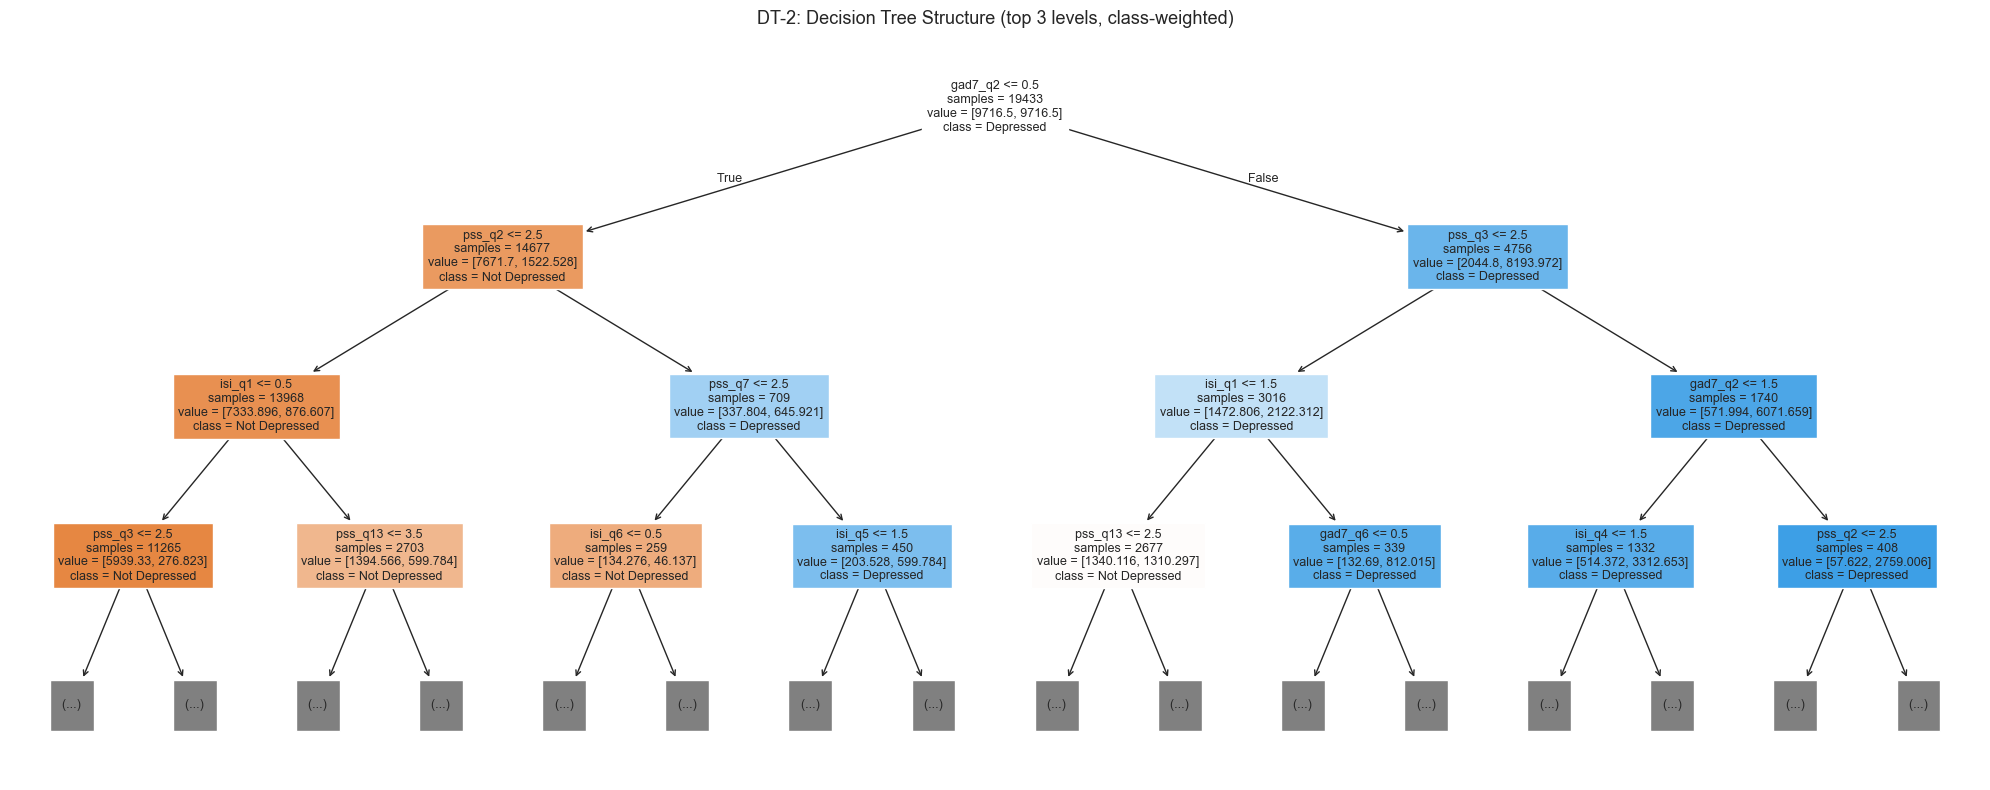

In [211]:

print("=" * 80)
print("DT-1: Baseline Decision Tree  [max_depth=5, no imbalance handling]")
print("=" * 80)

dt1 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt1.fit(X_train_cls, y_train_cls)
evaluate_model("DT-1: Baseline", dt1, X_test_cls, y_test_cls)

print("\n\n" + "=" * 80)
print("DT-2: Class-Weighted Decision Tree  [class_weight='balanced']")
print("=" * 80)

dt2 = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt2.fit(X_train_cls, y_train_cls)
evaluate_model("DT-2: Class-Weighted", dt2, X_test_cls, y_test_cls)

# ── Visualise the class-weighted tree (interpretable depth) ──
fig, ax = plt.subplots(figsize=(20, 8))
from sklearn.tree import plot_tree
plot_tree(dt2, max_depth=3, feature_names=predictor_cols,
          class_names=['Not Depressed', 'Depressed'],
          filled=True, impurity=False, fontsize=9, ax=ax)
ax.set_title('DT-2: Decision Tree Structure (top 3 levels, class-weighted)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/dt_structure.png', dpi=200, bbox_inches='tight')
print("\n✓ Saved: dt_structure.png")
plt.show()


In [212]:

print("=" * 80)
print("DT-3: SMOTE + Decision Tree")
print("=" * 80)

pipe_smote_dt = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   DecisionTreeClassifier(max_depth=5, random_state=42))
])
pipe_smote_dt.fit(X_train_cls, y_train_cls)
evaluate_model("DT-3: SMOTE", pipe_smote_dt, X_test_cls, y_test_cls)

print("\n\n" + "=" * 80)
print("DT-4: Random Undersampling + Decision Tree  [sampling_strategy=0.5]")
print(f"  Reduces majority to 2× minority; preserves more training data than 1:1.")
print("=" * 80)

pipe_under_dt = ImbPipeline([
    ('undersample', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ('clf',         DecisionTreeClassifier(max_depth=5, random_state=42))
])
pipe_under_dt.fit(X_train_cls, y_train_cls)
evaluate_model("DT-4: Undersampling (2:1)", pipe_under_dt, X_test_cls, y_test_cls)


DT-3: SMOTE + Decision Tree

──────────────────────────────────────────────────────────────
  DT-3: SMOTE
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.7728   ← misleading under imbalance
  Macro F1:            0.5828
  Minority Recall:     0.9049   ← depressed cases caught
  Minority Precision:  0.1807
  Minority F1:         0.3013
  ROC-AUC:             0.9158

  Confusion Matrix (rows=actual, cols=predicted):
               Pred 0   Pred 1
  Actual 0:     3517     1079   (true neg / false pos)
  Actual 1:       25      238   (false neg / true pos)


DT-4: Random Undersampling + Decision Tree  [sampling_strategy=0.5]
  Reduces majority to 2× minority; preserves more training data than 1:1.

──────────────────────────────────────────────────────────────
  DT-4: Undersampling (2:1)
──────────────────────────────────────────────────────────────
  Threshold:           0.50
  Accuracy:            0.8973   ← misleading u

({'Model': 'DT-4: Undersampling (2:1)',
  'Threshold': 0.5,
  'MacroF1': 0.6942,
  'MinRecall': 0.7605,
  'MinPrecision': 0.3145,
  'MinF1': 0.4449,
  'ROCAUC': 0.9136,
  'Accuracy': np.float64(0.8973),
  'TP': np.int64(200),
  'TN': np.int64(4160),
  'FP': np.int64(436),
  'FN': np.int64(63)},
 array([0.15137615, 0.0314304 , 0.45454545, ..., 0.15137615, 0.0314304 ,
        0.0314304 ], shape=(4859,)))

DT-5: Threshold Tuning on DT-2 (Class-Weighted Decision Tree)

  Optimal threshold: 0.83
  Minority F1 at optimal threshold: 0.5304


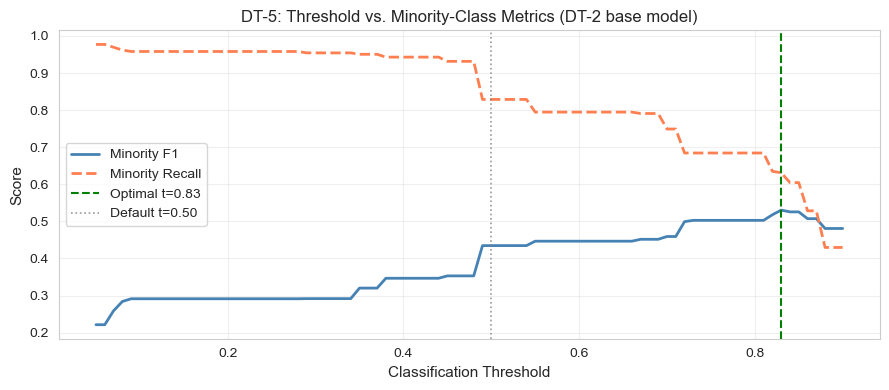


──────────────────────────────────────────────────────────────
  DT-5: Tuned Threshold
──────────────────────────────────────────────────────────────
  Threshold:           0.83
  Accuracy:            0.9395   ← misleading under imbalance
  Macro F1:            0.7490
  Minority Recall:     0.6312   ← depressed cases caught
  Minority Precision:  0.4573
  Minority F1:         0.5304
  ROC-AUC:             0.9271

  Confusion Matrix (rows=actual, cols=predicted):
               Pred 0   Pred 1
  Actual 0:     4399      197   (true neg / false pos)
  Actual 1:       97      166   (false neg / true pos)


({'Model': 'DT-5: Tuned Threshold',
  'Threshold': np.float64(0.8300000000000002),
  'MacroF1': 0.749,
  'MinRecall': 0.6312,
  'MinPrecision': 0.4573,
  'MinF1': 0.5304,
  'ROCAUC': 0.9271,
  'Accuracy': np.float64(0.9395),
  'TP': np.int64(166),
  'TN': np.int64(4399),
  'FP': np.int64(197),
  'FN': np.int64(97)},
 array([0.4887026 , 0.03520531, 0.4887026 , ..., 0.4887026 , 0.06067997,
        0.03520531], shape=(4859,)))

In [213]:

print("=" * 80)
print("DT-5: Threshold Tuning on DT-2 (Class-Weighted Decision Tree)")
print("=" * 80)

y_prob_dt2 = dt2.predict_proba(X_test_cls)[:, 1]

thresholds_dt = np.arange(0.05, 0.91, 0.01)
dt_f1_vals     = []
dt_recall_vals = []

for t in thresholds_dt:
    preds = (y_prob_dt2 >= t).astype(int)
    dt_f1_vals.append(f1_score(y_test_cls,     preds, pos_label=1, zero_division=0))
    dt_recall_vals.append(recall_score(y_test_cls, preds, pos_label=1, zero_division=0))

best_t_dt = thresholds_dt[np.argmax(dt_f1_vals)]
print(f"\n  Optimal threshold: {best_t_dt:.2f}")
print(f"  Minority F1 at optimal threshold: {max(dt_f1_vals):.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds_dt, dt_f1_vals,     color='steelblue', lw=2, label='Minority F1')
ax.plot(thresholds_dt, dt_recall_vals, color='coral', lw=2, linestyle='--', label='Minority Recall')
ax.axvline(best_t_dt, color='green', linestyle='--', lw=1.5, label=f'Optimal t={best_t_dt:.2f}')
ax.axvline(0.5,       color='gray',  linestyle=':',  lw=1.2, alpha=0.8, label='Default t=0.50')
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('DT-5: Threshold vs. Minority-Class Metrics (DT-2 base model)', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/dt_threshold_tuning.png', dpi=300, bbox_inches='tight')
plt.show()

evaluate_model("DT-5: Tuned Threshold", dt2, X_test_cls, y_test_cls, threshold=best_t_dt)


### 2.3 Model Comparison

All 12 models are compared on four metrics. **Accuracy is deliberately de-emphasized** — a classifier that predicts "not depressed" for everyone achieves 94.6% accuracy but catches zero cases.

| Metric | Why it matters |
|--------|---------------|
| **Macro F1** | Balanced performance across both classes |
| **Minority Recall** | Proportion of depressed cases correctly identified — top clinical priority |
| **Minority F1** | Harmonic mean of minority precision and recall |
| **ROC-AUC** | Overall discrimination ability, threshold-independent |


2.3  MODEL COMPARISON — All LR & DT Variants
                    Model  Threshold  MacroF1  MinRecall  MinPrecision  MinF1  ROCAUC  Accuracy
           LR-1: Baseline       0.50   0.7530     0.4106        0.7347 0.5268  0.9612    0.9601
     LR-2: Class-Weighted       0.50   0.7033     0.9163        0.3154 0.4693  0.9608    0.8878
LR-3: L2 + Class-Weighted       0.50   0.7006     0.9087        0.3120 0.4645  0.9611    0.8866
LR-4: L1 + Class-Weighted       0.50   0.7036     0.9163        0.3159 0.4698  0.9608    0.8880
              LR-5: SMOTE       0.50   0.7026     0.9049        0.3152 0.4676  0.9603    0.8885
LR-6: Undersampling (2:1)       0.50   0.7443     0.8365        0.3901 0.5320  0.9603    0.9204
    LR-7: Tuned Threshold       0.83   0.7979     0.6616        0.5819 0.6192  0.9611    0.9560
           DT-1: Baseline       0.50   0.7229     0.3498        0.7077 0.4682  0.9182    0.9570
     DT-2: Class-Weighted       0.50   0.6848     0.8289        0.2946 0.4347  0.9271    0.

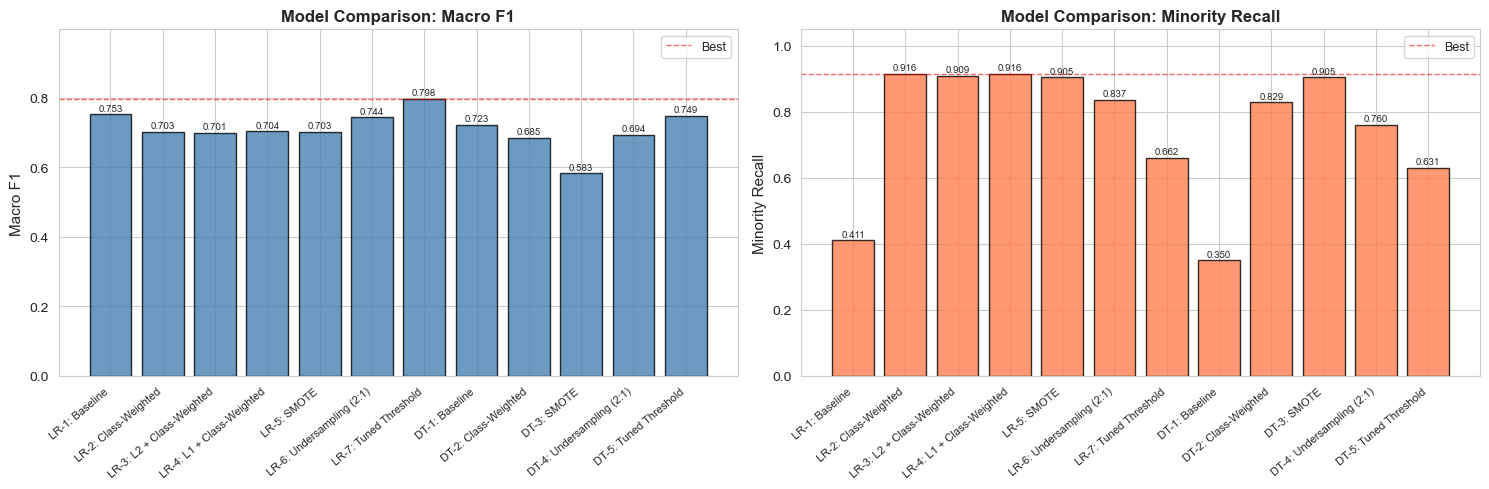

In [214]:

print("=" * 80)
print("2.3  MODEL COMPARISON — All LR & DT Variants")
print("=" * 80)

results_df = pd.DataFrame(results)

display_cols = ['Model', 'Threshold', 'MacroF1', 'MinRecall',
                'MinPrecision', 'MinF1', 'ROCAUC', 'Accuracy']
print(results_df[display_cols].to_string(index=False))

# ── Best model per metric ──
print("\n── Best model per metric ──")
for metric in ['MacroF1', 'MinRecall', 'MinF1', 'ROCAUC']:
    if results_df[metric].notna().any():
        best_row = results_df.loc[results_df[metric].idxmax()]
        print(f"  {metric:18s}: {best_row['Model']}  ({best_row[metric]:.4f})")

# ── Bar chart: Macro F1 and Minority Recall side by side ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(results_df))
width = 0.4

for ax, (metric, label, color) in zip(axes, [
    ('MacroF1',   'Macro F1',       'steelblue'),
    ('MinRecall', 'Minority Recall', 'coral'),
]):
    vals = results_df[metric].values
    bars = ax.bar(x, vals, color=color, edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['Model'], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'Model Comparison: {label}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, min(1.05, vals.max() * 1.25)])
    ax.axhline(vals.max(), color='red', linestyle='--', lw=1, alpha=0.6, label='Best')
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison.png")
plt.show()


ROC CURVES — LR Variants vs. DT Variants
✓ Saved: roc_curves.png


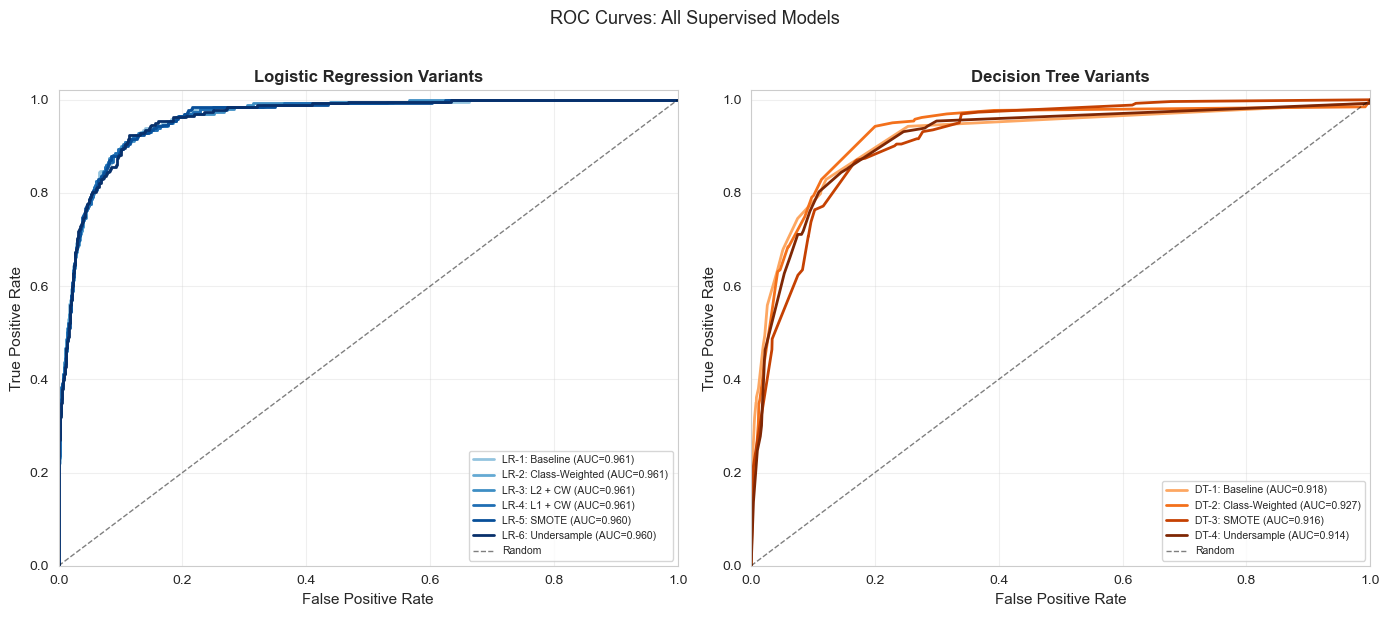

In [215]:

# ── ROC Curves for all models ──
print("=" * 80)
print("ROC CURVES — LR Variants vs. DT Variants")
print("=" * 80)

model_roc = [
    ("LR-1: Baseline",       lr1,           X_test_scaled, y_test_cls),
    ("LR-2: Class-Weighted", lr2,           X_test_scaled, y_test_cls),
    ("LR-3: L2 + CW",        lr3,           X_test_scaled, y_test_cls),
    ("LR-4: L1 + CW",        lr4,           X_test_scaled, y_test_cls),
    ("LR-5: SMOTE",          pipe_smote_lr, X_test_scaled, y_test_cls),
    ("LR-6: Undersample",    pipe_under_lr, X_test_scaled, y_test_cls),
    ("DT-1: Baseline",       dt1,           X_test_cls,    y_test_cls),
    ("DT-2: Class-Weighted", dt2,           X_test_cls,    y_test_cls),
    ("DT-3: SMOTE",          pipe_smote_dt, X_test_cls,    y_test_cls),
    ("DT-4: Undersample",    pipe_under_dt, X_test_cls,    y_test_cls),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_lr = plt.cm.Blues(np.linspace(0.4, 1.0, 6))
colors_dt = plt.cm.Oranges(np.linspace(0.4, 1.0, 4))

for ax, (model_subset, colors, title) in zip(axes, [
    (model_roc[:6], colors_lr, "Logistic Regression Variants"),
    (model_roc[6:], colors_dt, "Decision Tree Variants"),
]):
    for (name, model, Xt, yt), color in zip(model_subset, colors):
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(Xt)[:, 1]
            fpr, tpr, _ = roc_curve(yt, y_prob)
            auc_val = roc_auc_score(yt, y_prob)
            ax.plot(fpr, tpr, color=color, lw=2.0, label=f"{name} (AUC={auc_val:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7.5, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: All Supervised Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=300, bbox_inches='tight')
print("✓ Saved: roc_curves.png")
plt.show()


## Section III: Unsupervised Learning

**Goal:** Discover latent *worry-stress phenotypes* — subgroups of students with similar response profiles across the GAD-7, PSS-14, and ISI — **without using depression labels**.

**Why unsupervised here?**
The 28 scale items capture fine-grained variation in how students experience worry, stress, and insomnia. Clustering asks: *do naturally occurring symptom constellations exist?* I then post-hoc examine how depression prevalence differs across these phenotypes.

**Workflow (following lecture M4.1 / M4.2):**

| Step | Method | Purpose |
|------|--------|---------|
| 3.1 | PCA | Reduce 28 dimensions → visualise structure, interpret principal components |
| 3.2 | K-Means (elbow method) | Partition students into k worry-stress phenotypes |
| 3.3 | Cluster profiling | Characterise each phenotype by symptom profile and depression rate |

**Input features:** 28 item-level predictors (GAD-7 + PSS-14 + ISI), standardised. Demographic features are **excluded** — clustering should reflect the symptom space only.


In [216]:

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Feature matrix: 28 scale items only (no demographics) ──
# Clustering should reflect the worry-stress symptom space.
# Demographic features encode different constructs and are excluded.
scale_item_cols = gad7_item_cols + pss_item_cols + isi_item_cols   # 28 items

X_items = df_model[scale_item_cols].copy()

# Standardise — items have different ranges (GAD-7: 0–3, PSS: 1–5, ISI: 0–4).
# Without standardisation, PSS items would dominate PCA and K-Means distances.
scaler_unsup   = StandardScaler()
X_items_scaled = scaler_unsup.fit_transform(X_items)

print(f"Unsupervised feature matrix: {X_items_scaled.shape}")
print(f"  GAD-7: {len(gad7_item_cols)} items (0–3) | PSS: {len(pss_item_cols)} items (1–5) | ISI: {len(isi_item_cols)} items (0–4)")
print(f"  All items standardised to mean=0, std=1 before PCA and K-Means.")


Unsupervised feature matrix: (24292, 28)
  GAD-7: 7 items (0–3) | PSS: 14 items (1–5) | ISI: 7 items (0–4)
  All items standardised to mean=0, std=1 before PCA and K-Means.


### 3.1 Principal Component Analysis (PCA)

PCA rotates the 28-dimensional item space into orthogonal components ordered by how much variance they capture.

**What to look for:**
1. **Scree plot** — variance explained per component; the drop-off speed tells us whether a few components dominate
2. **Cumulative variance plot** — how many PCs are needed to reach 80% / 95% explained variance
3. **Loadings heatmap (PC1, PC2)** — which items drive each axis; this reveals the *psychological meaning* of each component
4. **PC1 vs PC2 scatter** — all participants in reduced 2D space, coloured by depression label

---

**Results (after running):**

- **PC1 (32.9% variance)** loads uniformly and positively across all 28 items — it is a **general symptom burden** axis. Participants with high PC1 score high on worry, stress, and insomnia simultaneously.
- **PC2 (19.0% variance)** contrasts PSS items 4–8 (positively framed items: *"been able to control irritations"*, etc.) against the negatively framed PSS items. This axis captures the **directionality contrast** built into the PSS scale design rather than a new psychological construct.
- **23 PCs are needed for 95% variance** — the item space does not compress well. This is expected: with 3 distinct scales measuring related but separable constructs, each item retains meaningful unique variance. Importantly, this *validates the TA feedback* to use item-level predictors rather than scale totals — aggregating would have destroyed the variation that lives in the higher PCs.
- The PCA scatter shows **depressed students concentrating along the positive PC1 axis** (far right), confirming PC1 captures a dimension closely tied to depression risk.

> **Note:** Because PCA compresses 28D into just 2D for visualisation, the clusters look messier here than they actually are in the full 28D space where K-Means operates. Do not judge cluster separation from the 2D plot alone.


STEP 1a: PCA — SCREE PLOT + CUMULATIVE VARIANCE

  PCs needed to explain ≥80% variance: 12
  PCs needed to explain ≥95% variance: 23

  Variance explained by first 5 PCs:
    PC1: 0.329  (32.9%)
    PC2: 0.190  (19.0%)
    PC3: 0.064  (6.4%)
    PC4: 0.045  (4.5%)
    PC5: 0.029  (2.9%)

✓ Saved: pca_scree.png


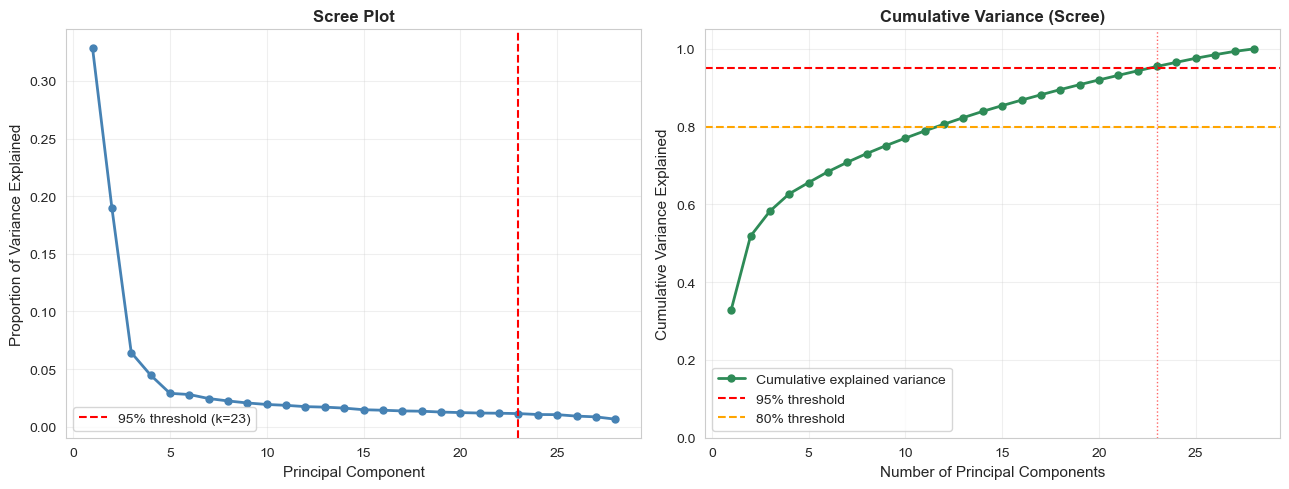

In [217]:

print("=" * 80)
print("STEP 1a: PCA — SCREE PLOT + CUMULATIVE VARIANCE")
print("=" * 80)

# Fit full PCA (retain all 28 components)
pca = PCA(n_components=28, random_state=42)
pca.fit(X_items_scaled)

evr     = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

n_80 = int(np.argmax(cum_evr >= 0.80)) + 1
n_95 = int(np.argmax(cum_evr >= 0.95)) + 1

print(f"\n  PCs needed to explain ≥80% variance: {n_80}")
print(f"  PCs needed to explain ≥95% variance: {n_95}")
print(f"\n  Variance explained by first 5 PCs:")
for i, v in enumerate(evr[:5]):
    print(f"    PC{i+1}: {v:.3f}  ({v*100:.1f}%)")

# ── Scree + cumulative variance plots ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree
axes[0].plot(range(1, 29), evr, 'o-', color='steelblue', lw=2, markersize=5)
axes[0].axvline(n_95, color='red', linestyle='--', lw=1.5,
                label=f'95% threshold (k={n_95})')
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Proportion of Variance Explained', fontsize=11)
axes[0].set_title('Scree Plot', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative
axes[1].plot(range(1, 29), cum_evr, 'o-', color='seagreen', lw=2, markersize=5,
             label='Cumulative explained variance')
axes[1].axhline(0.95, color='red',    linestyle='--', lw=1.5, label='95% threshold')
axes[1].axhline(0.80, color='orange', linestyle='--', lw=1.5, label='80% threshold')
axes[1].axvline(n_95, color='red',    linestyle=':',  lw=1,   alpha=0.6)
axes[1].set_xlabel('Number of Principal Components', fontsize=11)
axes[1].set_ylabel('Cumulative Variance Explained',  fontsize=11)
axes[1].set_title('Cumulative Variance (Scree)',     fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/pca_scree.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pca_scree.png")
plt.show()


STEP 1b: PC LOADINGS + PCA SCATTER COLOURED BY DEPRESSION

Top 8 items by |PC1 loading|:
gad7_q3    0.251
gad7_q4    0.247
gad7_q2    0.247
pss_q3     0.246
gad7_q6    0.246
pss_q2     0.242
gad7_q1    0.240
pss_q1     0.239
Name: PC1, dtype: float64

Top 8 items by |PC2 loading|:
pss_q6     0.375
pss_q5     0.366
pss_q9     0.357
pss_q7     0.353
pss_q4     0.346
pss_q10    0.330
pss_q13    0.319
pss_q12    0.292
Name: PC2, dtype: float64

✓ Saved: pca_loadings.png


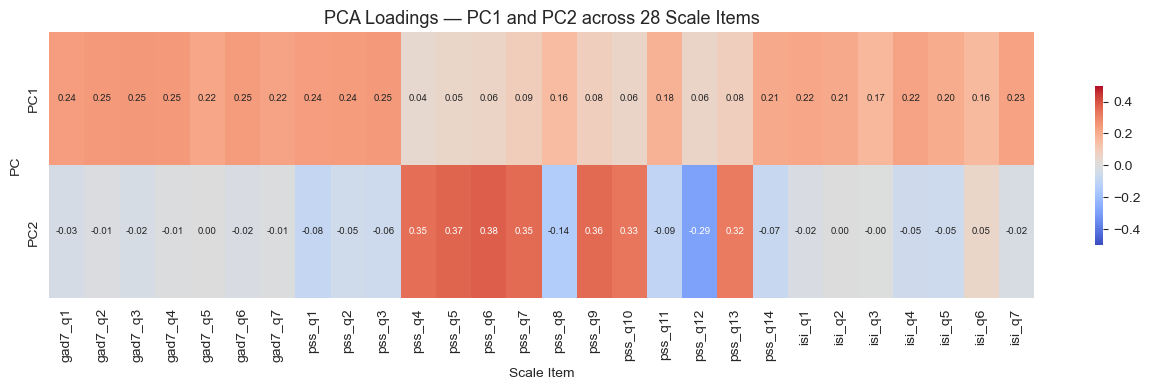

✓ Saved: pca_scatter_depression.png


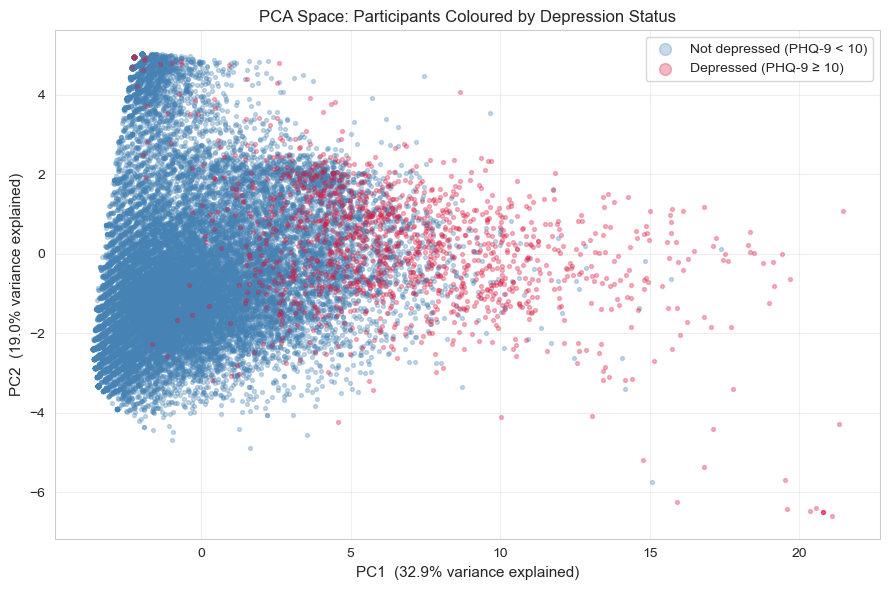

In [218]:

print("=" * 80)
print("STEP 1b: PC LOADINGS + PCA SCATTER COLOURED BY DEPRESSION")
print("=" * 80)

# ── Loadings heatmap (PC1 and PC2) ──
loadings_df = pd.DataFrame(
    pca.components_[:2].T,
    index=scale_item_cols,
    columns=['PC1', 'PC2']
)

print("\nTop 8 items by |PC1 loading|:")
print(loadings_df['PC1'].abs().sort_values(ascending=False).head(8).round(3))
print("\nTop 8 items by |PC2 loading|:")
print(loadings_df['PC2'].abs().sort_values(ascending=False).head(8).round(3))

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(loadings_df.T, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-0.5, vmax=0.5, ax=ax,
            cbar_kws={'shrink': 0.6}, annot_kws={'size': 7})
ax.set_title('PCA Loadings — PC1 and PC2 across 28 Scale Items', fontsize=13)
ax.set_xlabel('Scale Item', fontsize=10)
ax.set_ylabel('PC', fontsize=10)
plt.tight_layout()
plt.savefig('figures/pca_loadings.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pca_loadings.png")
plt.show()

# ── PC1 vs PC2 scatter coloured by depression status ──
X_pca = pca.transform(X_items_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
for label, color, name in [
    (0, 'steelblue', 'Not depressed (PHQ-9 < 10)'),
    (1, 'crimson',   'Depressed (PHQ-9 ≥ 10)'),
]:
    mask = df_model['depression_binary'].values == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.3, s=8, label=name)

ax.set_xlabel(f'PC1  ({evr[0]*100:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2  ({evr[1]*100:.1f}% variance explained)', fontsize=11)
ax.set_title('PCA Space: Participants Coloured by Depression Status', fontsize=12)
ax.legend(markerscale=3, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/pca_scatter_depression.png', dpi=300, bbox_inches='tight')
print("✓ Saved: pca_scatter_depression.png")
plt.show()


STEP 2: K-MEANS — ELBOW METHOD (k = 2 to 10)
  k= 2 | inertia = 532,171.4
  k= 3 | inertia = 440,321.7
  k= 4 | inertia = 404,001.7
  k= 5 | inertia = 383,362.0
  k= 6 | inertia = 369,539.9
  k= 7 | inertia = 358,521.5
  k= 8 | inertia = 349,584.0
  k= 9 | inertia = 342,449.6
  k=10 | inertia = 336,307.8

✓ Saved: kmeans_elbow.png


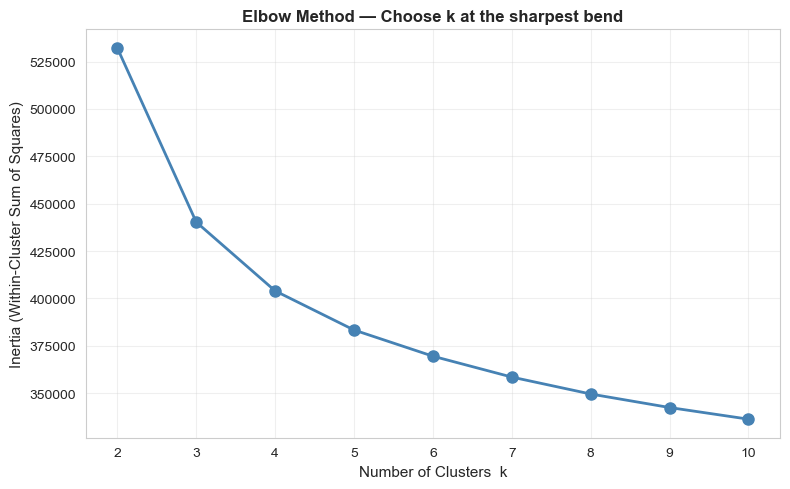

In [219]:

print("=" * 80)
print("STEP 2: K-MEANS — ELBOW METHOD (k = 2 to 10)")
print("=" * 80)

inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_items_scaled)
    inertias.append(km.inertia_)
    print(f"  k={k:2d} | inertia = {km.inertia_:,.1f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, 'o-', color='steelblue', lw=2, markersize=8)
ax.set_xlabel('Number of Clusters  k', fontsize=11)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
ax.set_title('Elbow Method — Choose k at the sharpest bend', fontsize=12, fontweight='bold')
ax.set_xticks(list(k_range))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/kmeans_elbow.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: kmeans_elbow.png")
plt.show()


### 3.2 K-Means Clustering

K-Means partitions students into k groups by minimising within-cluster sum of squares (inertia). Each cluster represents a **worry-stress phenotype** — a distinct pattern of item responses across GAD-7, PSS-14, and ISI.

**Choosing k** — I use the **elbow method**: plot inertia for k = 2 to 10 and select the k where the rate of decrease sharply flattens.

> Note: K-Means is sensitive to random initialisation. `n_init=10` runs 10 different seeds and keeps the best result; `random_state=42` ensures reproducibility.

---

**Results — elbow plot (after running):**

The sharpest drop is from k=2 → k=3 (~89k inertia reduction). The k=3 → k=4 drop is still notable (~35k). After k=4 the curve flattens considerably, with diminishing returns of ~15–20k per additional cluster.

**I chose k=4** rather than k=3 for two reasons:
1. k=4 produces a more psychologically interpretable phenotype structure, splitting what would be a single "mild" cluster into two meaningfully different groups (perceived-stress-dominant vs. mild all-domain).
2. The k=3 → k=4 inertia drop (~35k) is still large relative to later steps, so k=4 remains well-justified by the elbow criterion.


In [220]:

# ── k=4 chosen from elbow: sharpest bend at k=3→4, curve flattens after k=4.
# k=4 preferred over k=3 because it separates the "mild" group into two
# psychologically distinct phenotypes (stress-dominant vs. mild all-domain). ──
K_CHOSEN = 4

print("=" * 80)
print(f"STEP 3: FIT K-MEANS  (k={K_CHOSEN})")
print("=" * 80)

kmeans = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_items_scaled)
df_model['cluster'] = cluster_labels

# ── Phenotype labels assigned after inspecting STEP 4 cluster profiles ──
# Cluster 0: high PSS, very low GAD + ISI, 0.8% depression → stress perceived
#            but not internalised as worry or sleep disruption
# Cluster 1: mildly elevated across all three scales, 3.3% depression
#            → subclinical all-domain distress
# Cluster 2: near-zero on all scales, 0.0% depression → healthy reference group
# Cluster 3: high on all scales, 35.4% depression → severe multi-domain distress
phenotype_names = {
    0: 'Perceived Stress Only',
    1: 'Mild All-Domain',
    2: 'Minimal Symptoms',
    3: 'Severe Multi-Domain',
}

print(f"\nCluster sizes and depression rates:")
for c in range(K_CHOSEN):
    mask  = cluster_labels == c
    n_c   = mask.sum()
    dep_c = df_model.loc[mask, 'depression_binary'].mean()
    print(f"  Cluster {c} — {phenotype_names[c]}: "
          f"{n_c:6d} participants ({n_c/len(cluster_labels)*100:.1f}%)  |  "
          f"depression rate: {dep_c*100:.1f}%")

print(f"\n  Inertia (within-cluster SS): {kmeans.inertia_:.1f}")


STEP 3: FIT K-MEANS  (k=4)

Cluster sizes and depression rates:
  Cluster 0 — Perceived Stress Only:   4186 participants (17.2%)  |  depression rate: 0.8%
  Cluster 1 — Mild All-Domain:   7406 participants (30.5%)  |  depression rate: 3.3%
  Cluster 2 — Minimal Symptoms:   9770 participants (40.2%)  |  depression rate: 0.0%
  Cluster 3 — Severe Multi-Domain:   2930 participants (12.1%)  |  depression rate: 35.4%

  Inertia (within-cluster SS): 404001.7


STEP 4: CLUSTER PROFILING

Depression rate (PHQ-9 ≥ 10) per phenotype:
  Cluster 0 [Perceived Stress Only]: 0.8%  (n=4186)
  Cluster 1 [Mild All-Domain]: 3.3%  (n=7406)
  Cluster 2 [Minimal Symptoms]: 0.0%  (n=9770)
  Cluster 3 [Severe Multi-Domain]: 35.4%  (n=2930)  (6.5× overall rate)
  Overall: 5.4%

Mean scale totals per phenotype:
         gad7_total  pss_total  isi_total  phq9_total
cluster                                              
0              0.32      26.80       0.97        1.32
1              2.62      22.63       3.75        4.58
2              0.32      12.16       1.02        1.26
3              7.73      29.68       8.76        9.39

✓ Saved: cluster_profiles.png


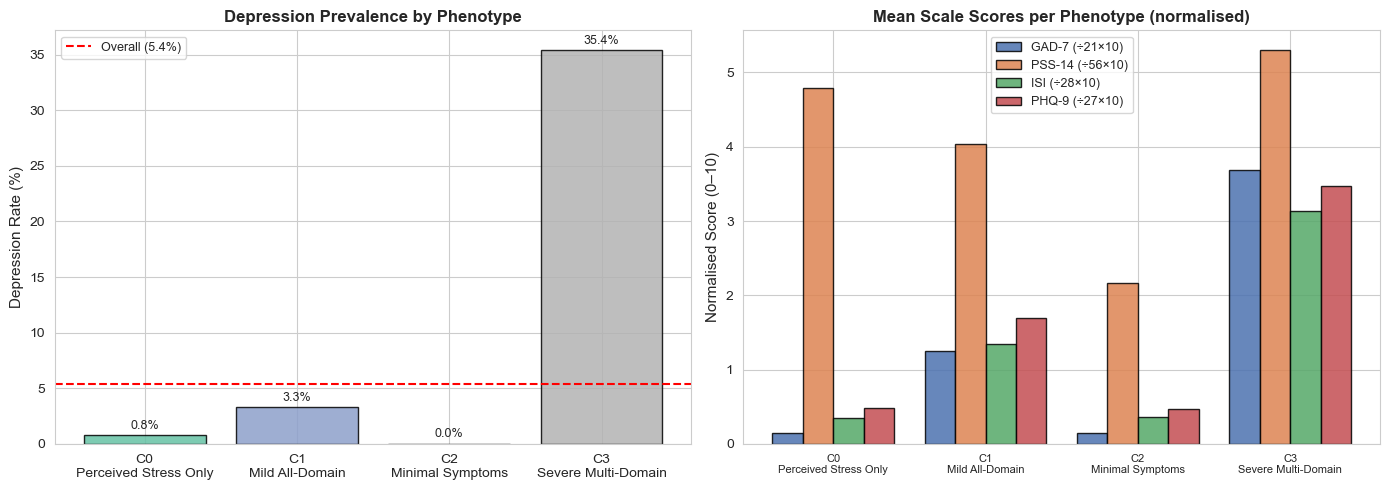

In [221]:

print("=" * 80)
print("STEP 4: CLUSTER PROFILING")
print("=" * 80)

dep_rate     = df_model.groupby('cluster')['depression_binary'].mean()
cluster_size = df_model.groupby('cluster').size()
overall_rate = df_model['depression_binary'].mean()

print("\nDepression rate (PHQ-9 ≥ 10) per phenotype:")
for c in range(K_CHOSEN):
    ratio  = dep_rate[c] / overall_rate
    marker = f'  ({ratio:.1f}× overall rate)' if dep_rate[c] > overall_rate else ''
    print(f"  Cluster {c} [{phenotype_names[c]}]: "
          f"{dep_rate[c]*100:.1f}%  (n={cluster_size[c]}){marker}")
print(f"  Overall: {overall_rate*100:.1f}%")

profile_cols    = ['gad7_total', 'pss_total', 'isi_total', 'phq9_total']
cluster_profile = df_model.groupby('cluster')[profile_cols].mean().round(2)
print("\nMean scale totals per phenotype:")
print(cluster_profile.to_string())

# ── Visualise ──
# Use phenotype names as x-axis labels (shortened for readability)
short_names   = [f'C{c}\n{phenotype_names[c]}' for c in range(K_CHOSEN)]
cluster_colors = plt.cm.Set2(np.linspace(0, 1, K_CHOSEN))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Depression rate bar
bars = axes[0].bar(short_names, dep_rate.values * 100,
                   color=cluster_colors, edgecolor='black', alpha=0.85)
axes[0].axhline(overall_rate * 100, color='red', linestyle='--', lw=1.5,
                label=f'Overall ({overall_rate*100:.1f}%)')
axes[0].set_ylabel('Depression Rate (%)', fontsize=11)
axes[0].set_title('Depression Prevalence by Phenotype', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
for bar, v in zip(bars, dep_rate.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)

# Normalised mean scale scores
scale_meta = [
    ('gad7_total', 'GAD-7',  21, '#4C72B0'),
    ('pss_total',  'PSS-14', 56, '#DD8452'),
    ('isi_total',  'ISI',    28, '#55A868'),
    ('phq9_total', 'PHQ-9',  27, '#C44E52'),
]
x     = np.arange(K_CHOSEN)
width = 0.2
for i, (col, label, maxval, color) in enumerate(scale_meta):
    vals = cluster_profile[col].values / maxval * 10
    axes[1].bar(x + i * width, vals, width, label=f'{label} (÷{maxval}×10)',
                color=color, alpha=0.85, edgecolor='black')

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(short_names, fontsize=8)
axes[1].set_ylabel('Normalised Score (0–10)', fontsize=11)
axes[1].set_title('Mean Scale Scores per Phenotype (normalised)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/cluster_profiles.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: cluster_profiles.png")
plt.show()


STEP 5: CLUSTERS IN PCA SPACE
✓ Saved: clusters_pca_space.png


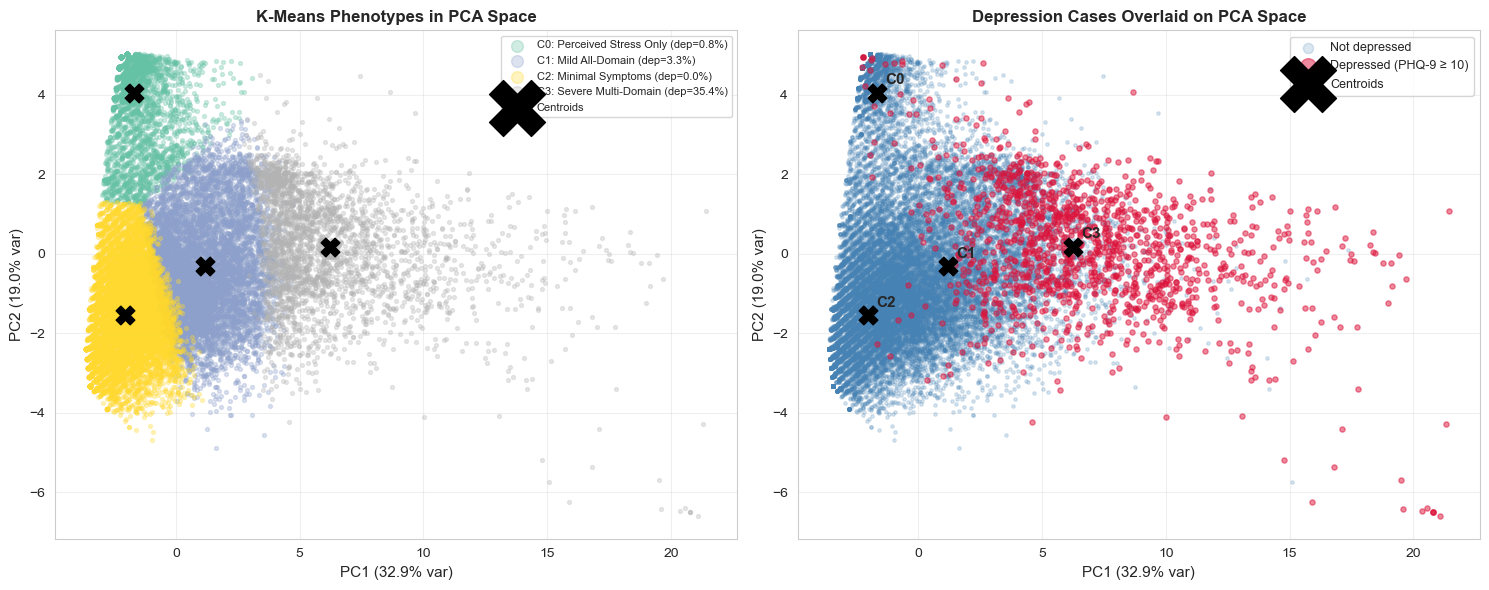


── Unsupervised Summary ──
  23 PCs explain ≥95% of variance — item space is high-dimensional.
  K-Means (k=4) identified 4 phenotypes:
    C0 [Perceived Stress Only]: 0.8% depression  (n=4186)
    C1 [Mild All-Domain]: 3.3% depression  (n=7406)
    C2 [Minimal Symptoms]: 0.0% depression  (n=9770)
    C3 [Severe Multi-Domain]: 35.4% depression  (n=2930)


In [222]:

print("=" * 80)
print("STEP 5: CLUSTERS IN PCA SPACE")
print("=" * 80)

centroids_pca  = pca.transform(kmeans.cluster_centers_)
cluster_palette = plt.cm.Set2(np.linspace(0, 1, K_CHOSEN))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: participants coloured by phenotype ──
for c in range(K_CHOSEN):
    mask  = cluster_labels == c
    dep_c = df_model.loc[mask, 'depression_binary'].mean()
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[cluster_palette[c]], alpha=0.3, s=8,
                    label=f'C{c}: {phenotype_names[c]} (dep={dep_c*100:.1f}%)')

axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=180, zorder=5, label='Centroids')
axes[0].set_xlabel(f'PC1 ({evr[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({evr[1]*100:.1f}% var)', fontsize=11)
axes[0].set_title('K-Means Phenotypes in PCA Space', fontsize=12, fontweight='bold')
axes[0].legend(markerscale=3, fontsize=8, loc='upper right')
axes[0].grid(alpha=0.3)

# ── Right: depressed cases overlaid ──
dep_mask     = df_model['depression_binary'].values == 1
not_dep_mask = ~dep_mask

axes[1].scatter(X_pca[not_dep_mask, 0], X_pca[not_dep_mask, 1],
                c='steelblue', alpha=0.2, s=6, label='Not depressed')
axes[1].scatter(X_pca[dep_mask, 0], X_pca[dep_mask, 1],
                c='crimson', alpha=0.5, s=14, label='Depressed (PHQ-9 ≥ 10)')
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=180, zorder=5, label='Centroids')
for c, (cx, cy) in enumerate(centroids_pca[:, :2]):
    axes[1].annotate(f'C{c}', (cx, cy), textcoords='offset points',
                     xytext=(6, 6), fontsize=11, fontweight='bold')

axes[1].set_xlabel(f'PC1 ({evr[0]*100:.1f}% var)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({evr[1]*100:.1f}% var)', fontsize=11)
axes[1].set_title('Depression Cases Overlaid on PCA Space', fontsize=12, fontweight='bold')
axes[1].legend(markerscale=3, fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/clusters_pca_space.png', dpi=300, bbox_inches='tight')
print("✓ Saved: clusters_pca_space.png")
plt.show()

# ── Printed summary ──
print(f"\n── Unsupervised Summary ──")
print(f"  {n_95} PCs explain ≥95% of variance — item space is high-dimensional.")
print(f"  K-Means (k={K_CHOSEN}) identified 4 phenotypes:")
for c in range(K_CHOSEN):
    print(f"    C{c} [{phenotype_names[c]}]: {dep_rate[c]*100:.1f}% depression  (n={cluster_size[c]})")


### 3.3 Evaluating Unsupervised Models

Unlike supervised learning, there is no ground-truth label to compute accuracy against. Evaluation uses two complementary strategies:

**Internal metrics** — measure cluster quality using only the feature data (no labels):

| Metric | What it measures | Better when |
|--------|-----------------|-------------|
| **Silhouette score** | How similar each point is to its own cluster vs. the nearest other cluster | Closer to +1 |
| **Davies-Bouldin index** | Ratio of within-cluster scatter to between-cluster separation | Closer to 0 |
| **Calinski-Harabasz score** | Ratio of between-cluster to within-cluster dispersion | Higher |

**External validation** — I have held-out variables that were *never used in clustering*. Two approaches, applied to PHQ-9:

| Test | Variable used | Why |
|------|--------------|-----|
| **Chi-square** | Binary depression (PHQ-9 ≥ 10) | Tests whether cluster composition differs from chance; familiar and easy to report |
| **One-way ANOVA + η²** | Continuous PHQ-9 total score | More powerful — uses the full score, not a binary cut. **η² (eta-squared)** is the proportion of PHQ-9 variance explained by cluster membership; directly interpretable as effect size |
| **Tukey HSD post-hoc** | Continuous PHQ-9 total score | After a significant ANOVA, identifies *which pairs* of phenotypes differ significantly |

ANOVA is run on all four scales (PHQ-9, GAD-7, PSS-14, ISI) to confirm the clusters differ on *every* symptom dimension, not just depression — validating them as genuine multi-domain phenotypes.

> **Why external validation is particularly strong here:** the clusters were derived purely from worry-stress *symptom patterns*. Finding that one cluster has a 35.4% depression rate and a dramatically higher mean PHQ-9 — without ever seeing the PHQ-9 labels during clustering — demonstrates that the phenotypes have genuine predictive meaning, not just statistical artefact.


In [223]:

from sklearn.metrics import silhouette_score

print("=" * 80)
print("STEP 6: INTERNAL CLUSTER EVALUATION — Silhouette Score")
print("=" * 80)
print("  Silhouette score measures how similar each point is to its own cluster")
print("  compared to the nearest other cluster. Range: -1 (wrong cluster) to +1")
print("  (well-separated). Does NOT use depression labels — purely internal.\n")

# Computed on a 5k subsample for speed (full 24k takes several minutes)
np.random.seed(42)
sample_idx = np.random.choice(len(X_items_scaled), size=5000, replace=False)
sil_score  = silhouette_score(X_items_scaled[sample_idx], cluster_labels[sample_idx])

print(f"  Silhouette Score: {sil_score:.4f}")
print()
print("  Interpretation:")
print("    > 0.50  → strong cluster structure")
print("    0.20–0.50 → reasonable structure (typical for psychological data)")
print("    < 0.20  → weak or overlapping clusters")
print()
print("  Note: psychological scale items overlap by design (they measure related")
print("  constructs), so silhouette scores above 0.5 are rarely achieved in this")
print("  domain. A moderate silhouette combined with large depression rate")
print("  differences across clusters is the more meaningful result here.")


STEP 6: INTERNAL CLUSTER EVALUATION — Silhouette Score
  Silhouette score measures how similar each point is to its own cluster
  compared to the nearest other cluster. Range: -1 (wrong cluster) to +1
  (well-separated). Does NOT use depression labels — purely internal.

  Silhouette Score: 0.2031

  Interpretation:
    > 0.50  → strong cluster structure
    0.20–0.50 → reasonable structure (typical for psychological data)
    < 0.20  → weak or overlapping clusters

  Note: psychological scale items overlap by design (they measure related
  constructs), so silhouette scores above 0.5 are rarely achieved in this
  domain. A moderate silhouette combined with large depression rate
  differences across clusters is the more meaningful result here.


In [224]:

from scipy.stats import chi2_contingency

print("=" * 80)
print("STEP 7: EXTERNAL VALIDATION — Cluster × Depression")
print("=" * 80)
print("  Unsupervised clusters were built without depression labels.")
print("  I now test whether cluster membership is statistically associated")
print("  with depression (PHQ-9 ≥ 10) using a chi-square test of independence.")

# Contingency table: clusters (rows) × depression status (cols)
contingency = pd.crosstab(df_model['cluster'], df_model['depression_binary'],
                           rownames=['Cluster'], colnames=['Depressed (0=No, 1=Yes)'])
contingency.index = [f'C{c}: {phenotype_names[c]}' for c in range(K_CHOSEN)]
print("\nContingency table (counts):")
print(contingency.to_string())

chi2, p_val, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_val:.2e}")
print(f"\n→ {'Significant' if p_val < 0.001 else 'Not significant'} association "
      f"between cluster and depression (α=0.001).")
print("  The clusters differ strongly in depression prevalence even though")
print("  depression labels were never used during clustering — confirming that")
print("  worry-stress symptom patterns are meaningful predictors of depression risk.")

# Odds ratio: Severe Multi-Domain vs rest
severe_mask = df_model['cluster'] == 3
or_dep_rate = df_model.loc[severe_mask,  'depression_binary'].mean()
ot_dep_rate = df_model.loc[~severe_mask, 'depression_binary'].mean()
odds_ratio  = (or_dep_rate / (1 - or_dep_rate)) / (ot_dep_rate / (1 - ot_dep_rate))
print(f"\nOdds ratio — 'Severe Multi-Domain' vs. all other clusters:")
print(f"  OR = {odds_ratio:.1f}  (students in Cluster 3 are {odds_ratio:.0f}× more likely to be depressed)")


STEP 7: EXTERNAL VALIDATION — Cluster × Depression
  Unsupervised clusters were built without depression labels.
  I now test whether cluster membership is statistically associated
  with depression (PHQ-9 ≥ 10) using a chi-square test of independence.

Contingency table (counts):
Depressed (0=No, 1=Yes)       0     1
C0: Perceived Stress Only  4153    33
C1: Mild All-Domain        7163   243
C2: Minimal Symptoms       9767     3
C3: Severe Multi-Domain    1893  1037

Chi-square statistic: 5932.18
Degrees of freedom:   3
p-value:              0.00e+00

→ Significant association between cluster and depression (α=0.001).
  The clusters differ strongly in depression prevalence even though
  depression labels were never used during clustering — confirming that
  worry-stress symptom patterns are meaningful predictors of depression risk.

Odds ratio — 'Severe Multi-Domain' vs. all other clusters:
  OR = 41.4  (students in Cluster 3 are 41× more likely to be depressed)


STEP 8: ONE-WAY ANOVA + EFFECT SIZE (η²) — Clusters × Scale Scores
  ANOVA tests whether mean *continuous* scale scores differ across phenotypes.
  More powerful than chi-square: uses the full score, not a binary cutoff.

  Summary across all four scales:
  Scale             F            p       η²  Effect size
  ----------------------------------------------------
  PHQ-9        9204.9     0.00e+00   0.5320  large
  GAD-7       16259.8     0.00e+00   0.6676  large
  PSS-14      16141.4     0.00e+00   0.6660  large
  ISI          9589.7     0.00e+00   0.5422  large

  η² interpretation (Cohen): small ≥ 0.01 | medium ≥ 0.06 | large ≥ 0.14

✓ Saved: anova_evaluation.png


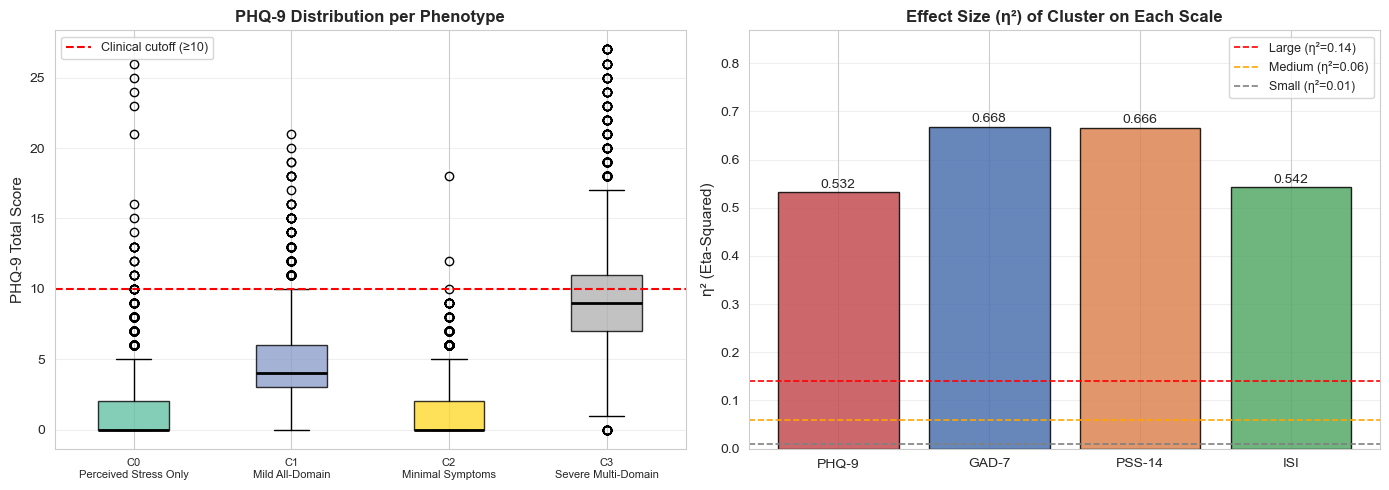

In [225]:

from scipy.stats import f_oneway

print("=" * 80)
print("STEP 8: ONE-WAY ANOVA + EFFECT SIZE (η²) — Clusters × Scale Scores")
print("=" * 80)
print("  ANOVA tests whether mean *continuous* scale scores differ across phenotypes.")
print("  More powerful than chi-square: uses the full score, not a binary cutoff.\n")

def anova_eta(col, label):
    groups     = [df_model.loc[df_model['cluster'] == c, col].values for c in range(K_CHOSEN)]
    F, p       = f_oneway(*groups)
    grand_mean = df_model[col].mean()
    SS_total   = ((df_model[col] - grand_mean) ** 2).sum()
    SS_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    eta_sq     = SS_between / SS_total
    size       = 'large' if eta_sq >= 0.14 else 'medium' if eta_sq >= 0.06 else 'small'
    return dict(Scale=label, F=round(F, 1), p=p, eta_sq=round(eta_sq, 4), effect=size)

scales_to_test = [
    ('phq9_total', 'PHQ-9'),
    ('gad7_total', 'GAD-7'),
    ('pss_total',  'PSS-14'),
    ('isi_total',  'ISI'),
]

anova_results = [anova_eta(col, lbl) for col, lbl in scales_to_test]
anova_df      = pd.DataFrame(anova_results)
anova_df['p_str'] = anova_df['p'].apply(lambda p: f'{p:.2e}')

print("  Summary across all four scales:")
print(f"  {'Scale':8s} {'F':>10s} {'p':>12s} {'η²':>8s}  Effect size")
print(f"  {'-'*52}")
for _, row in anova_df.iterrows():
    print(f"  {row['Scale']:8s} {row['F']:>10.1f} {row['p_str']:>12s} "
          f"{row['eta_sq']:>8.4f}  {row['effect']}")
print("\n  η² interpretation (Cohen): small ≥ 0.01 | medium ≥ 0.06 | large ≥ 0.14")

# ── Two plots: PHQ-9 box plot + η² bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: PHQ-9 distribution per phenotype
cluster_colors = plt.cm.Set2(np.linspace(0, 1, K_CHOSEN))
bp_data = [df_model.loc[df_model['cluster'] == c, 'phq9_total'].values for c in range(K_CHOSEN)]
bp = axes[0].boxplot(bp_data, patch_artist=True, notch=False,
                     medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], cluster_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_xticklabels([f'C{c}\n{phenotype_names[c]}' for c in range(K_CHOSEN)], fontsize=8)
axes[0].set_ylabel('PHQ-9 Total Score', fontsize=11)
axes[0].set_title('PHQ-9 Distribution per Phenotype', fontsize=12, fontweight='bold')
axes[0].axhline(10, color='red', linestyle='--', lw=1.5, label='Clinical cutoff (≥10)')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# η² bar chart with Cohen's threshold lines
bars = axes[1].bar(anova_df['Scale'], anova_df['eta_sq'],
                   color=['#C44E52', '#4C72B0', '#DD8452', '#55A868'],
                   edgecolor='black', alpha=0.85)
axes[1].axhline(0.14, color='red',    linestyle='--', lw=1.2, label='Large (η²=0.14)')
axes[1].axhline(0.06, color='orange', linestyle='--', lw=1.2, label='Medium (η²=0.06)')
axes[1].axhline(0.01, color='gray',   linestyle='--', lw=1.2, label='Small (η²=0.01)')
axes[1].set_ylabel('η² (Eta-Squared)', fontsize=11)
axes[1].set_title('Effect Size (η²) of Cluster on Each Scale', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim([0, min(1.0, anova_df['eta_sq'].max() * 1.3)])
for bar, v in zip(bars, anova_df['eta_sq']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/anova_evaluation.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: anova_evaluation.png")
plt.show()
